# 4. EDA — Análise Exploratória de Dados

Quarta fase do CRISP-DM. Aqui as sete hipóteses formuladas no notebook 01 são testadas estatisticamente, usando as técnicas vistas no material da Fase 1: testes de hipóteses para diferença de médias, testes de proporções, intervalos de confiança, correlação de Pearson, regressão linear simples e múltipla (incluindo termos de interação) e distribuição binomial.

A organização do notebook segue a agenda de hipóteses:

- **4.1** Carregamento e setup
- **4.2** Panorama univariado das variáveis vs. a target
- **4.3** H1: ponto de ruptura em `delivery_time_days`
- **4.4** H2: interação `delivery_delay_days` × `order_value`
- **4.5** H3: Service Recovery Paradox
- **4.6** H4: blind spots `csat_internal_score` vs. `nps_score`
- **4.7** H5: NPS prediz recompra
- **4.8** H6: detrator silencioso
- **4.9** H7: região explicada por operacional
- **4.10** Síntese: o que cada hipótese mostrou
- **4.11** Insights de negócio consolidados
- **4.12** Conclusão da fase

Cada seção de hipótese segue o mesmo padrão: pergunta de pesquisa, método estatístico aplicado, resultado quantitativo, interpretação de negócio. As decisões metodológicas vão sempre justificar a escolha técnica em função do que o negócio precisa entender.

## 4.1 Carregamento e setup

Diferente dos notebooks anteriores que carregavam o CSV bruto, esta fase parte do **dataset processado** salvo em `data/processed/dados_processados.csv`. As transformações aplicadas no notebook 03 (categorização do NPS, conversões para `Categorical`, variáveis log derivadas, renomeação) já estão presentes, e a função do módulo `src/nps/data.py` reconstrói os tipos categóricos automaticamente na leitura.

O setup visual segue o padrão dos notebooks anteriores: tema seaborn whitegrid, paleta de cores semânticas para os buckets de NPS (vermelho para detrator, cinza para neutro, verde para promotor) reaproveitada em toda a EDA.

In [1]:
# Bibliotecas principais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Funcoes do nosso modulo
from nps.data import carregar_dataset_processado
from nps.features import CATEGORIAS_NPS_ORDEM

# Reprodutibilidade
SEMENTE_ALEATORIA = 42
np.random.seed(SEMENTE_ALEATORIA)

# Configuracao visual padrao
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

# Cores semanticas que serao usadas em todas as visualizacoes da EDA
CORES_BUCKETS = {
    "detrator": "#e74c3c",
    "neutro":   "#95a5a6",
    "promotor": "#27ae60",
}
ORDEM_BUCKETS = list(CATEGORIAS_NPS_ORDEM)

# Caminhos para esse notebook
RAIZ_PROJETO = Path.cwd().parent
PASTA_FIGURAS = RAIZ_PROJETO / "reports" / "figures" / "04_eda"
PASTA_FIGURAS.mkdir(parents=True, exist_ok=True)

# Carrega o dataset processado (com tipos categoricos reconstituidos)
dados = carregar_dataset_processado()

print(f"Dataset processado carregado: {dados.shape[0]:,} linhas x {dados.shape[1]} colunas")
print(f"Tipos das colunas categoricas reconstituidas:")
print(f"  categoria_nps:    {dados['categoria_nps'].dtype}, ordenada={dados['categoria_nps'].cat.ordered}")
print(f"  customer_region:  {dados['customer_region'].dtype}, ordenada={dados['customer_region'].cat.ordered}")

Dataset processado carregado: 2,500 linhas x 23 colunas
Tipos das colunas categoricas reconstituidas:
  categoria_nps:    category, ordenada=True
  customer_region:  category, ordenada=False


Tudo carregado conforme esperado: 2.500 linhas, 23 colunas, com `categoria_nps` ordenada (detrator < neutro < promotor) e `customer_region` não-ordenada. As variáveis derivadas no notebook 03 (`log_order_value`, `log_discount_value`, `houve_recompra_30d`) também estão disponíveis. A próxima seção começa com um panorama univariado das variáveis em relação à target, antes de mergulhar nas hipóteses específicas.

## 4.2 Panorama univariado: correlação com a target

Antes de testar as hipóteses específicas, vale ter uma visão geral de como cada variável numérica se relaciona com o `nps_score`. A ferramenta para isso é a **correlação de Pearson**, que mede o grau de associação linear entre duas variáveis numéricas e produz um valor entre -1 e +1: valores próximos de +1 indicam que as duas variáveis sobem juntas, próximos de -1 que uma sobe quando a outra desce, e próximos de 0 que não há associação linear clara.

Vou olhar primeiro o panorama completo (todas contra todas) e depois um recorte focado em quem mais correlaciona com a target. Esse é um passo de **descoberta exploratória**, não conclusão: correlações altas vão virar pontos de partida para os testes formais nas próximas seções, e correlações próximas de zero vão receber atenção especial nas hipóteses sobre relações não-lineares.

### Por que Pearson, e não outra medida

Pearson é o coeficiente padrão para variáveis numéricas em escala razoavelmente normal e foi visto no material da fase 1. Tem uma limitação importante: ele só capta **relação linear**. Se uma variável afeta o NPS de forma não-linear (por exemplo, "abaixo de 5 dias o efeito é zero, acima de 8 a queda é forte"), o coeficiente de Pearson pode estar próximo de zero mesmo que a relação real seja forte. Isso vai ser importante para a interpretação da hipótese H1 mais adiante.

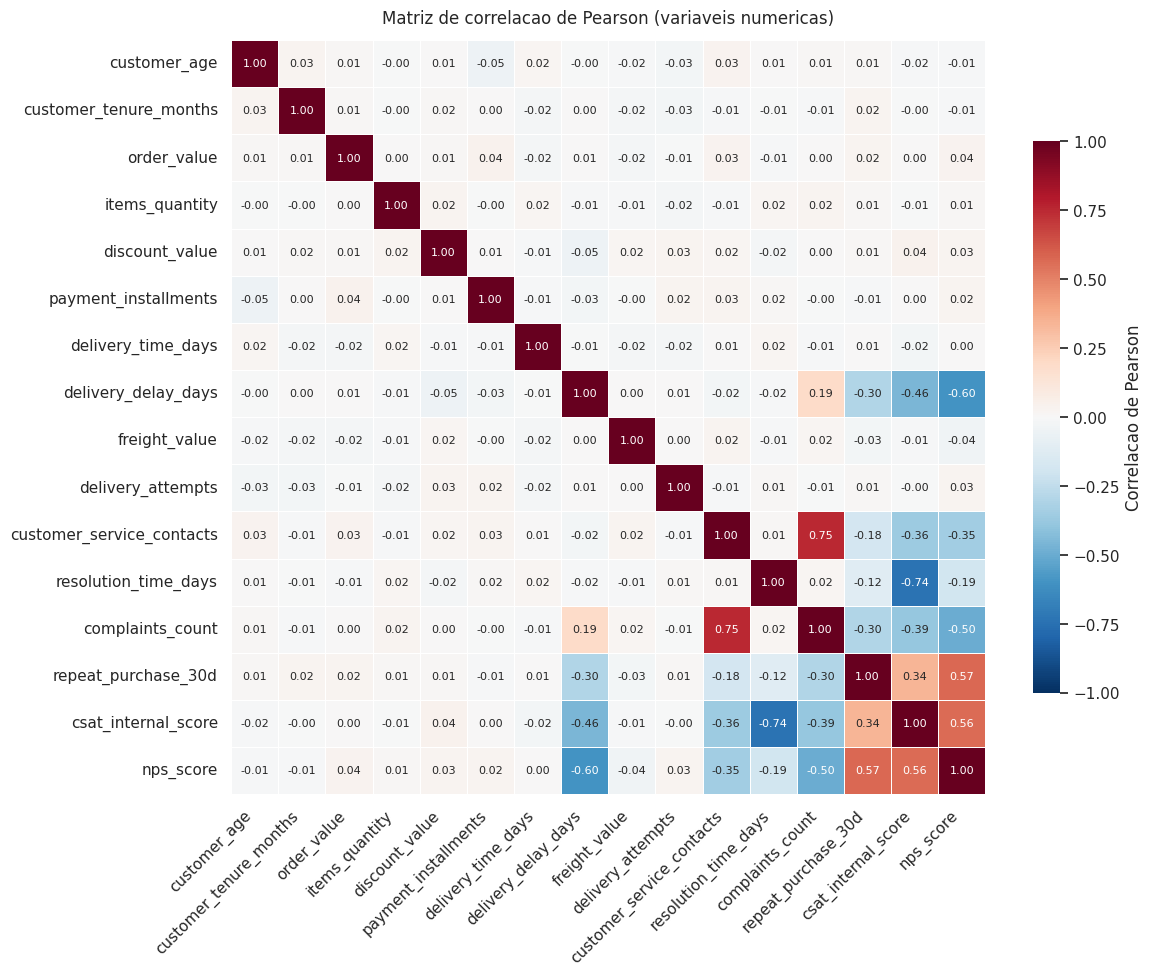

In [2]:
# Variaveis numericas relevantes (excluindo IDs e a copia houve_recompra_30d)
variaveis_numericas = [
    "customer_age", "customer_tenure_months",
    "order_value", "items_quantity", "discount_value", "payment_installments",
    "delivery_time_days", "delivery_delay_days", "freight_value", "delivery_attempts",
    "customer_service_contacts", "resolution_time_days", "complaints_count",
    "repeat_purchase_30d",
    "csat_internal_score",
    "nps_score",
]

# Matriz de correlacao de Pearson
matriz_corr = dados[variaveis_numericas].corr(method="pearson")

# Heatmap divergente em torno de zero
fig, eixo = plt.subplots(figsize=(12, 10))
sns.heatmap(
    matriz_corr,
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.7, "label": "Correlacao de Pearson"},
    ax=eixo,
)
eixo.set_title("Matriz de correlacao de Pearson (variaveis numericas)", fontsize=12, pad=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "4_2_heatmap_correlacao.png", dpi=120, bbox_inches="tight")
plt.show()

![Matriz de correlação de Pearson das variáveis numéricas](../reports/figures/04_eda/4_2_heatmap_correlacao.png)

**Como ler este gráfico:** uma **matriz quadrada** onde cada linha e cada coluna representa uma variável numérica. Cada célula mostra o **coeficiente de correlação de Pearson** entre as duas variáveis cruzadas, com o valor numérico anotado dentro. A escala de cores vai de **azul forte (correlação negativa, próxima de -1)** a **vermelho forte (correlação positiva, próxima de +1)**, passando pelo branco em zero (sem correlação linear). A **diagonal principal sempre é vermelho intenso (1,00)** porque é a correlação de cada variável com ela mesma. Para entender o impacto de cada variável na target, basta olhar a **linha ou coluna do `nps_score`** e identificar as cores mais fortes.

Algumas leituras importantes do heatmap.

**Coluna do `nps_score` (que é o que mais nos interessa nesta fase):** as cores mais fortes aparecem em poucas variáveis, e em duas direções diferentes.

Em **azul (correlação negativa)**, três variáveis se destacam: `delivery_delay_days`, `complaints_count` e `customer_service_contacts`. Faz sentido econômico: cliente com mais atraso, mais reclamações ou mais contatos no SAC tende a dar nota menor de NPS. A magnitude de `delivery_delay_days` (em torno de -0,60) é a maior associação linear negativa do dataset com a target.

Em **vermelho (correlação positiva)**, duas variáveis aparecem com força semelhante: `csat_internal_score` (aproximadamente +0,56) e `repeat_purchase_30d` (+0,57). A correlação alta com CSAT confirma a preocupação que tínhamos sobre target leakage (CSAT carrega informação parecida com a do NPS). A correlação alta com recompra é boa notícia para a hipótese H5: já antecipa que NPS deve mesmo prever recompra.

**Variáveis com correlação próxima de zero** com o NPS: idade, tenure, valor do pedido, quantidade de itens, parcelas, frete e tentativas de entrega têm coeficientes praticamente nulos. Isso era esperado para algumas dessas (idade, tenure parecem ter sido sorteadas independentemente da target no dataset sintético), mas há um caso suspeito: `delivery_time_days`. Logicamente, era para ter alguma relação, mas o coeficiente Pearson dela com NPS é praticamente zero.

**Atenção a esse achado:** Pearson capta só relação linear. Se o efeito do tempo de entrega for tipo "abaixo de 5 dias o NPS não muda muito; acima de 8 dias o NPS desaba", isso pode produzir correlação Pearson próxima de zero mesmo com relação real forte. Esse é exatamente o cenário descrito pela hipótese H1, e justifica investigar a variável com técnica diferente (segmentação por faixas) na seção 4.3.

**Outras observações úteis** que vão importar para a modelagem mais adiante: variáveis de atendimento têm correlações moderadas entre si (`complaints_count` × `customer_service_contacts`, `customer_service_contacts` × `resolution_time_days`), o que é colinearidade esperada. `freight_value` correlaciona positivamente com `order_value` (frete tende a subir com pedido maior). Nada disso surpreende, mas é bom ter mapeado.

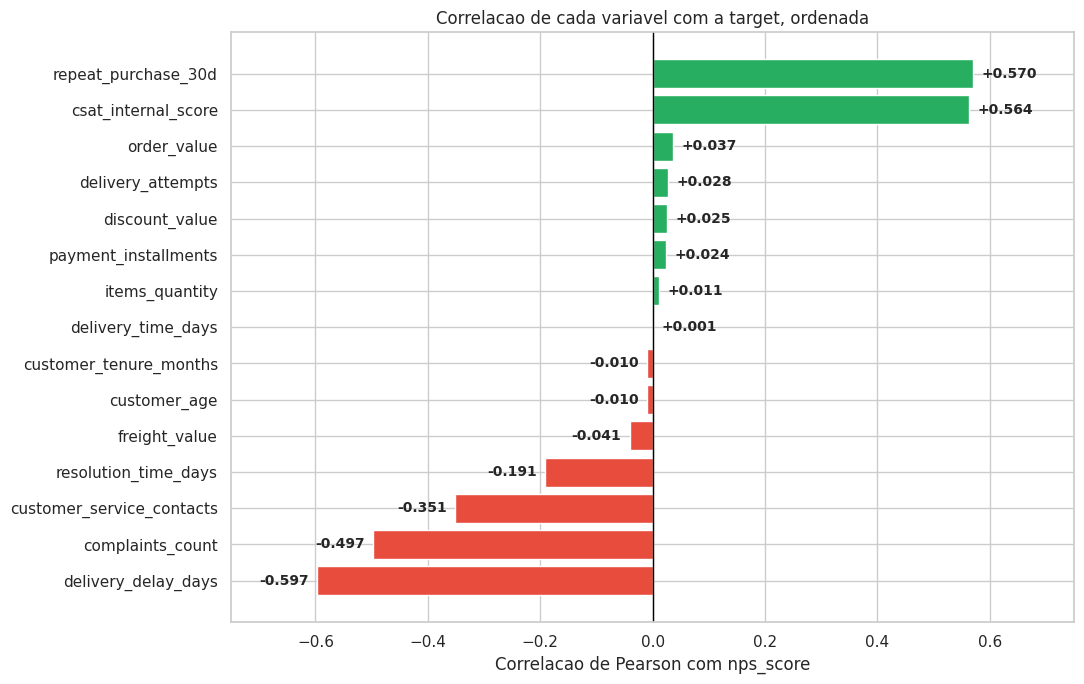

In [3]:
# Bar chart focado na correlacao de cada variavel com a target
correlacoes_com_nps = matriz_corr["nps_score"].drop("nps_score").sort_values()

# Cores: vermelho para correlacao negativa, verde para positiva
cores_barras = ["#e74c3c" if v < 0 else "#27ae60" for v in correlacoes_com_nps.values]

fig, eixo = plt.subplots(figsize=(11, 7))
barras = eixo.barh(correlacoes_com_nps.index, correlacoes_com_nps.values, color=cores_barras, edgecolor="white")

# Anota o valor numerico em cada barra
for i, v in enumerate(correlacoes_com_nps.values):
    deslocamento = 0.015 if v >= 0 else -0.015
    alinhamento = "left" if v >= 0 else "right"
    eixo.text(v + deslocamento, i, f"{v:+.3f}", va="center", ha=alinhamento, fontsize=10, fontweight="bold")

eixo.axvline(0, color="black", linewidth=1)
eixo.set_xlim(-0.75, 0.75)
eixo.set_xlabel("Correlacao de Pearson com nps_score")
eixo.set_title("Correlacao de cada variavel com a target, ordenada")
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "4_2_correlacao_com_nps.png", dpi=120, bbox_inches="tight")
plt.show()

![Correlação de cada variável com a target ordenada](../reports/figures/04_eda/4_2_correlacao_com_nps.png)

**Como ler este gráfico:** o eixo X mostra o **coeficiente de correlação de Pearson** com `nps_score`, indo de -0,75 a +0,75. Cada barra horizontal é uma variável do dataset, ordenada da mais negativa (no topo) para a mais positiva (em baixo). **Barras vermelhas** indicam correlação negativa (a variável tende a baixar o NPS); **verdes** indicam correlação positiva (tendem a subir). O comprimento de cada barra é proporcional à força da relação. A linha vertical preta em zero é a referência para distinguir os dois lados, e barras muito curtas (próximas dela) significam variáveis sem relação linear detectável com a target.

O bar chart deixa o ranking explícito. Em valor absoluto, a hierarquia das correlações lineares com NPS é:

1. `delivery_delay_days` (-0,60)
2. `repeat_purchase_30d` (+0,57)
3. `csat_internal_score` (+0,56)
4. `complaints_count` (-0,50)
5. `customer_service_contacts` (-0,35)
6. `resolution_time_days` (-0,19)

E uma cauda longa de variáveis com correlação praticamente nula (`freight_value`, `customer_age`, `customer_tenure_months`, `delivery_time_days`, `items_quantity`, `payment_installments`, `discount_value`, `delivery_attempts`).

Esse panorama dá três pistas importantes para a sequência da EDA.

A **logística está claramente associada à target**, principalmente via atraso (`delivery_delay_days`), o que era a expectativa. A interação dessa variável com `order_value`, prevista pela hipótese H2, vai ser testada formalmente na seção 4.4.

O **atendimento entra como segundo bloco mais relevante**, mas com a ressalva já discutida no notebook 01: contatos com SAC e reclamações são possivelmente sintoma do problema, não causa. As hipóteses H3 (Service Recovery Paradox) e H6 (detrator silencioso) vão tentar separar esses efeitos.

E o **mistério do `delivery_time_days` quase nulo** vai ser o foco da hipótese H1: existe um ponto de ruptura, ou a variável de tempo total realmente não importa? Como Pearson é cego para não-linearidade, vamos precisar de outra abordagem para responder.

Com esse panorama em mente, as próximas seções vão testar cada uma das sete hipóteses formuladas no notebook 01.

## 4.3 Hipótese H1: ponto de ruptura em `delivery_time_days`

A hipótese H1, formulada na seção 1.6 do notebook 01, dizia que **existe um ponto de ruptura no `delivery_time_days` acima do qual o NPS cai de forma desproporcional ao aumento do tempo**. O panorama de correlações da seção 4.2 trouxe um sinal estranho: a correlação Pearson entre `delivery_time_days` e `nps_score` é praticamente zero. Mas isso não basta para rejeitar a hipótese, porque Pearson só capta relação linear. Se de fato existe um ponto de ruptura, a relação é não-linear, e Pearson seria cego para ela.

A forma certa de investigar é segmentar a variável em **faixas de interpretação de negócio** e comparar o NPS médio entre elas. Se houver ruptura, o NPS deve cair de forma visível ao passar de uma faixa para outra mais lenta.

### Faixas de tempo de entrega

Vou usar quatro categorias com significado prático para o negócio, todas dentro do range observado (2 a 14 dias):

| Faixa | Tempo |
|---|---|
| Rápido | até 3 dias |
| Normal | 4 a 7 dias |
| Lento | 8 a 11 dias |
| Muito lento | 12 dias ou mais |

Esses cortes refletem expectativas reais do mercado brasileiro de e-commerce: até 3 dias é território de "entrega rápida" tipo Amazon Prime e Mercado Livre Full; 4 a 7 dias é o padrão da maioria das plataformas; 8 a 11 começa a virar lento; 12 dias ou mais é considerado pesado.

NPS medio por faixa de tempo de entrega:
                     mean    std  count  ic_min  ic_max
delivery_time_days                                     
Rapido (<=3d)       4.294  2.551    386   4.040   4.548
Normal (4-7d)       4.439  2.470    752   4.262   4.616
Lento (8-11d)       4.391  2.511    757   4.212   4.570
Muito lento (12+d)  4.342  2.537    605   4.140   4.544


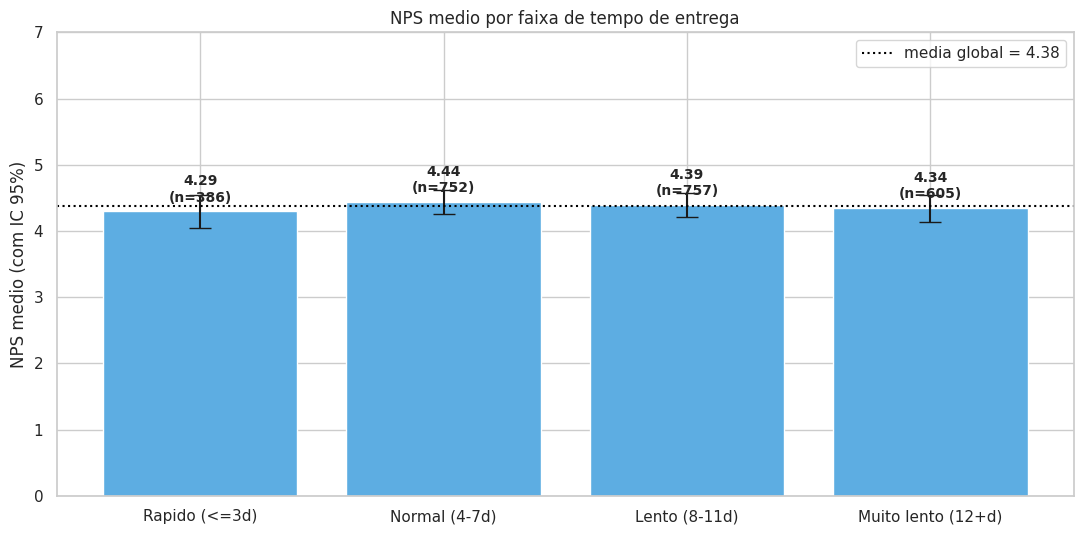

In [4]:
from scipy import stats

# Cria a coluna de faixa baseada em interpretacao de negocio
faixa_entrega = pd.cut(
    dados["delivery_time_days"],
    bins=[-float("inf"), 3, 7, 11, float("inf")],
    labels=["Rapido (<=3d)", "Normal (4-7d)", "Lento (8-11d)", "Muito lento (12+d)"],
)

# Calcula media, std, n e IC 95% para cada faixa
estats = dados.groupby(faixa_entrega, observed=True)["nps_score"].agg(["mean", "std", "count"]).round(3)
estats["se"] = estats["std"] / np.sqrt(estats["count"])
estats["ic_min"] = estats["mean"] - 1.96 * estats["se"]
estats["ic_max"] = estats["mean"] + 1.96 * estats["se"]

print("NPS medio por faixa de tempo de entrega:")
print(estats[["mean", "std", "count", "ic_min", "ic_max"]].round(3).to_string())

# Bar chart com error bars representando o IC 95%
fig, eixo = plt.subplots(figsize=(11, 5.5))
faixas_ordem = list(estats.index)
medias = estats["mean"].values
ic_baixo = (estats["mean"] - estats["ic_min"]).values
ic_alto = (estats["ic_max"] - estats["mean"]).values

barras = eixo.bar(
    faixas_ordem, medias,
    yerr=[ic_baixo, ic_alto],
    capsize=8,
    color="#5dade2",
    edgecolor="white",
)
for i, (m, n) in enumerate(zip(medias, estats["count"].values)):
    eixo.text(i, m + 0.15, f"{m:.2f}\n(n={n:,})", ha="center", fontsize=10, fontweight="bold")

# Linha da media global como referencia
media_global = dados["nps_score"].mean()
eixo.axhline(media_global, color="black", linestyle=":", linewidth=1.5, label=f"media global = {media_global:.2f}")

eixo.set_ylabel("NPS medio (com IC 95%)")
eixo.set_title("NPS medio por faixa de tempo de entrega")
eixo.set_ylim(0, 7)
eixo.legend(loc="upper right")
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "4_3_nps_por_faixa_entrega.png", dpi=120, bbox_inches="tight")
plt.show()

![NPS médio por faixa de tempo de entrega](../reports/figures/04_eda/4_3_nps_por_faixa_entrega.png)

**Como ler este gráfico:** o eixo X tem as quatro faixas de tempo de entrega definidas por interpretação de negócio. A **altura de cada barra** é o NPS médio dos clientes daquela faixa, com o valor exato e o tamanho do grupo (n) anotados em cima. As **linhas verticais pretas no topo** são intervalos de confiança a 95%: representam o range provável onde está a média verdadeira da população, considerando a incerteza amostral. Quando os ICs de duas barras se sobrepõem, é um sinal forte de que as médias podem ser iguais. A **linha pontilhada preta horizontal** marca a média global do NPS no dataset, servindo como linha de referência.

O gráfico mostra um resultado **surpreendente e contraintuitivo**: as quatro faixas têm NPS médio praticamente idêntico, todos perto de 4,4. As barras de erro (intervalos de confiança a 95%) se sobrepõem entre as faixas, o que já é um forte indicativo visual de que não há diferença estatisticamente significativa.

Em outras palavras: cliente que recebeu o pedido em 3 dias dá nota parecida com cliente que recebeu em 14 dias. Não há ponto de ruptura visível, e nem mesmo uma queda gradual. A linha pontilhada da média global passa por todas as barras dentro do intervalo de confiança.

Vamos confirmar isso com um teste de hipóteses formal antes de cravar a conclusão.

In [5]:
# Teste t de Welch (variancias diferentes) entre o grupo mais rapido e o mais lento.
# Hipotese nula H0: medias iguais. Hipotese alternativa H1: medias diferentes.

grupo_rapido = dados[faixa_entrega == "Rapido (<=3d)"]["nps_score"]
grupo_muito_lento = dados[faixa_entrega == "Muito lento (12+d)"]["nps_score"]

t_stat, p_valor = stats.ttest_ind(grupo_rapido, grupo_muito_lento, equal_var=False)
diferenca_medias = grupo_rapido.mean() - grupo_muito_lento.mean()

# Intervalo de confianca 95% para a diferenca de medias (formula classica)
se_diff = np.sqrt(grupo_rapido.var(ddof=1) / len(grupo_rapido) +
                  grupo_muito_lento.var(ddof=1) / len(grupo_muito_lento))
ic_min_diff = diferenca_medias - 1.96 * se_diff
ic_max_diff = diferenca_medias + 1.96 * se_diff

print(f"Grupo Rapido (<=3d):       n = {len(grupo_rapido):>4,}, media = {grupo_rapido.mean():.3f}")
print(f"Grupo Muito lento (12+d):  n = {len(grupo_muito_lento):>4,}, media = {grupo_muito_lento.mean():.3f}")
print()
print(f"Diferenca de medias (rapido - muito lento): {diferenca_medias:+.3f}")
print(f"IC 95% para a diferenca: [{ic_min_diff:+.3f}, {ic_max_diff:+.3f}]")
print()
print(f"Estatistica t (Welch):     {t_stat:.3f}")
print(f"P-valor:                   {p_valor:.4f}")
print(f"Decisao a 5% de significancia: {'rejeitamos H0 (medias diferentes)' if p_valor < 0.05 else 'nao rejeitamos H0 (medias iguais)'}")

Grupo Rapido (<=3d):       n =  386, media = 4.294
Grupo Muito lento (12+d):  n =  605, media = 4.342

Diferenca de medias (rapido - muito lento): -0.048
IC 95% para a diferenca: [-0.373, +0.277]

Estatistica t (Welch):     -0.288
P-valor:                   0.7733
Decisao a 5% de significancia: nao rejeitamos H0 (medias iguais)


O teste t de Welch confirma o que o gráfico mostrava. A diferença de médias entre o grupo mais rápido e o mais lento é de apenas -0,048 pontos de NPS, e o intervalo de confiança a 95% inclui o zero (vai de aproximadamente -0,37 a +0,28). Isso significa que não temos evidência estatística suficiente para dizer que as médias são diferentes. O p-valor é alto (em torno de 0,77), muito acima do limiar usual de 5%.

**Conclusão sobre a hipótese H1:** rejeitada pelos dados. O tempo total de entrega, sozinho, não tem efeito detectável no NPS desta base. Não existe ponto de ruptura.

### O que isso significa de verdade

Esse resultado parece desconfortável à primeira vista, mas faz sentido quando combinado com o que vimos na seção 4.2: enquanto `delivery_time_days` tem correlação Pearson praticamente zero com NPS, `delivery_delay_days` (atraso em relação ao prometido) tem correlação de -0,60. Essa diferença é o achado central da seção.

A leitura de negócio é forte: **o cliente não fica satisfeito porque a entrega foi rápida em termos absolutos; ele fica satisfeito quando a empresa cumpre o prazo prometido**. Cliente que comprou um item de baixa prioridade e ouviu "entrega em 12 dias" está psicologicamente preparado para esperar 12 dias; se receber no prazo, ele não pune. O que machuca o NPS é a quebra de promessa, não o tempo em si.

Essa descoberta vira uma frase clara para o slide executivo:

> "Reduzir o tempo médio de entrega não é a alavanca prioritária para subir o NPS. A alavanca real é reduzir os atrasos, ou seja, melhorar a precisão da promessa, não a velocidade absoluta."

Operacionalmente, isso muda o tipo de investimento que faz sentido para a empresa: melhorar previsibilidade da operação (reduzir desvios) é provavelmente mais barato e mais impactante que tentar reduzir o tempo médio para todos os pedidos. A hipótese H2, na próxima seção, vai aprofundar esse efeito do atraso, agora em interação com o valor do pedido.

## 4.4 Hipótese H2: interação `delivery_delay_days` × `order_value`

A hipótese H2 dizia que **a tolerância a atraso depende do valor do pedido**, na direção esperada pelo negócio: cliente que paga mais (ticket alto) seria mais sensível a atrasos do que cliente que paga menos. A forma estatística de testar isso é uma **regressão linear múltipla com termo de interação**: ajustar dois modelos, um sem interação e outro com, e verificar se o termo de interação melhora a explicação da variabilidade do NPS de forma significativa.

A técnica usada é exatamente o que foi visto na aula de regressão linear: estimar coeficientes, ler p-valores e comparar R² entre modelos. Vou usar a biblioteca `statsmodels`, que produz a saída em formato de tabela acadêmica padrão.

In [6]:
import statsmodels.formula.api as smf

# Modelo 1: efeito principal das duas variaveis, sem interacao
modelo_1 = smf.ols("nps_score ~ delivery_delay_days + order_value", data=dados).fit()

# Modelo 2: com termo de interacao delivery_delay_days * order_value
# A notacao "*" no statsmodels gera os efeitos principais E o termo de interacao automaticamente.
modelo_2 = smf.ols("nps_score ~ delivery_delay_days * order_value", data=dados).fit()

print("=== MODELO 1 (sem interacao) ===")
print(modelo_1.summary().tables[1])
print(f"R-quadrado: {modelo_1.rsquared:.4f}")

print("\n=== MODELO 2 (com interacao) ===")
print(modelo_2.summary().tables[1])
print(f"R-quadrado: {modelo_2.rsquared:.4f}")

print(f"\nGanho de R-quadrado ao adicionar a interacao: {modelo_2.rsquared - modelo_1.rsquared:+.4f}")
print(f"P-valor do coeficiente de interacao: {modelo_2.pvalues['delivery_delay_days:order_value']:.4f}")

=== MODELO 1 (sem interacao) ===
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               6.4815      0.094     68.807      0.000       6.297       6.666
delivery_delay_days    -1.0312      0.028    -37.273      0.000      -1.085      -0.977
order_value             0.0004      0.000      2.530      0.011     7.9e-05       0.001
R-quadrado: 0.3584

=== MODELO 2 (com interacao) ===
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                           6.4316      0.131     49.160      0.000       6.175       6.688
delivery_delay_days                -1.0080      0.050    -19.990      0.000      -1.107      -0.909
order_value                         0.0005      0.000      1.838      0.06

**Como ler a tabela de coeficientes:** cada linha é uma variável (ou termo) do modelo. As colunas mostram, da esquerda para a direita: o **coeficiente estimado** (`coef`), o erro padrão (`std err`), a estatística de teste (`t`), o **p-valor** (`P>|t|`) e o intervalo de confiança a 95% (`[0.025, 0.975]`).

A regra prática é: o coeficiente diz quanto a target muda quando a variável aumenta em uma unidade. O p-valor responde "se o coeficiente verdadeiro for zero, qual a probabilidade de eu ver um valor desse por acaso?". Quanto menor, mais evidência contra o coeficiente ser zero. **P-valor abaixo de 0,05 indica significância estatística** ao nível de 5%.

O `R-quadrado` no rodapé é a fração da variância da target explicada pelo modelo (entre 0 e 1). Quanto mais alto, melhor o modelo se ajustou aos dados.

Lendo os números, três coisas saltam da tabela.

**No Modelo 1:** o coeficiente de `delivery_delay_days` é -1,03 (cada dia de atraso reduz o NPS em aproximadamente 1 ponto), com p-valor praticamente zero (forte evidência de efeito real). O coeficiente de `order_value` é minúsculo (+0,0004), com p-valor borderline (0,011). O R² é 0,36, o que significa que essas duas variáveis sozinhas já explicam **36% da variabilidade do NPS**, um número alto considerando que estamos usando apenas duas variáveis.

**No Modelo 2:** o termo de interação `delivery_delay_days:order_value` tem coeficiente de -5,46 × 10⁻⁵ e **p-valor de 0,58**, longe de significativo. O R² do modelo com interação é praticamente idêntico ao sem interação (0,3584 vs 0,3584).

**Conclusão sobre a hipótese H2:** rejeitada pelos dados. Não há evidência de que clientes com pedidos de valor mais alto sejam mais sensíveis a atrasos do que clientes de pedidos baratos. O efeito do atraso é estatisticamente o mesmo, independente do `order_value`.

Antes de fechar a interpretação, vale visualizar isso para confirmar a leitura dos coeficientes.

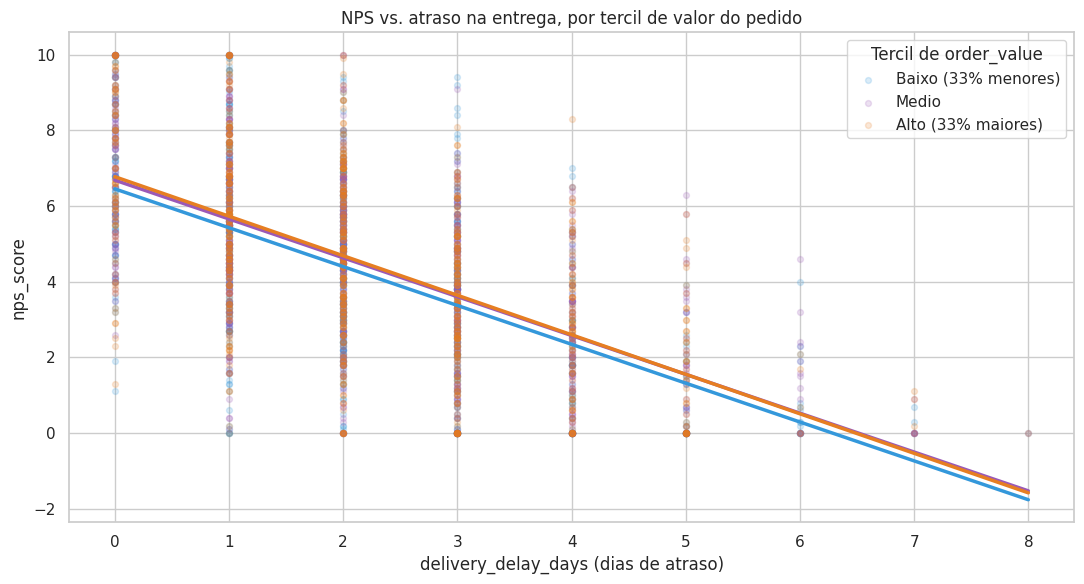

In [7]:
# Visualizacao da interacao: scatter de delivery_delay_days vs nps_score, colorido por
# tercil de order_value. Se houver interacao real, as 3 linhas de tendencia teriam
# inclinacoes diferentes; se nao houver, as inclinacoes serao parecidas.

dados_viz = dados.copy()
dados_viz["tercil_pedido"] = pd.qcut(
    dados_viz["order_value"],
    q=3,
    labels=["Baixo (33% menores)", "Medio", "Alto (33% maiores)"],
)

# Cores diferentes para cada tercil
paleta_tercis = {
    "Baixo (33% menores)": "#3498db",
    "Medio":               "#9b59b6",
    "Alto (33% maiores)":  "#e67e22",
}

fig, eixo = plt.subplots(figsize=(11, 6))

# Para cada tercil, plota os pontos com leve transparencia e a linha de regressao
for nome_tercil, cor in paleta_tercis.items():
    subset = dados_viz[dados_viz["tercil_pedido"] == nome_tercil]
    sns.regplot(
        data=subset,
        x="delivery_delay_days",
        y="nps_score",
        scatter_kws={"alpha": 0.18, "s": 18, "color": cor},
        line_kws={"color": cor, "linewidth": 2.5},
        ci=None,
        ax=eixo,
        label=nome_tercil,
    )

eixo.set_xlabel("delivery_delay_days (dias de atraso)")
eixo.set_ylabel("nps_score")
eixo.set_title("NPS vs. atraso na entrega, por tercil de valor do pedido")
eixo.legend(title="Tercil de order_value", loc="upper right")
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "4_4_interacao_atraso_valor.png", dpi=120, bbox_inches="tight")
plt.show()

![NPS vs atraso por tercil de valor do pedido](../reports/figures/04_eda/4_4_interacao_atraso_valor.png)

**Como ler este gráfico:** o eixo X mostra os dias de atraso na entrega; o eixo Y mostra o `nps_score`. Cada ponto é um pedido individual, e os clientes foram divididos em **três grupos pelos tercis do `order_value`**: 33% com pedidos de menor valor (azul), 33% intermediários (roxo), 33% com pedidos de maior valor (laranja).

Para cada grupo foi traçada uma **linha de regressão linear simples** (`nps_score ~ delivery_delay_days` dentro do grupo). A inclinação dessa linha indica quanto o NPS cai por cada dia de atraso, naquele grupo específico.

**O que procurar para confirmar ou rejeitar H2:** se a hipótese estiver correta (clientes de ticket alto mais sensíveis), a linha laranja deveria ter inclinação **mais negativa** (mais íngreme para baixo) do que as outras duas. Se as três linhas tiverem inclinação parecida, todos os clientes reagem de forma equivalente ao atraso, e a hipótese cai.

As três linhas estão **praticamente paralelas e sobrepostas**. A inclinação é aproximadamente a mesma em todos os tercis: cada dia de atraso reduz o NPS em algo próximo de 1 ponto, independente de o cliente ter feito um pedido barato, médio ou caro. Isso confirma visualmente o que o modelo de regressão já tinha mostrado: não existe interação significativa entre `delivery_delay_days` e `order_value`.

### Interpretação de negócio

O resultado contradiz uma intuição comum. Faz sentido pensar que cliente que pagou caro deveria ficar mais furioso com atraso, mas no nosso dataset isso não acontece. **Atraso machuca todos os clientes mais ou menos na mesma medida**, e o que define quanto o NPS cai é a magnitude do atraso, não o valor do pedido.

Essa descoberta tem três implicações práticas para a empresa.

**Não vale priorizar logística por ticket.** Estratégias como "vamos garantir entrega no prazo só para pedidos acima de R$ 500" não vão fazer o NPS subir tanto quanto seria esperado, porque cliente de R$ 100 também está sendo punido pelo atraso na mesma proporção.

**A alavanca correta é universal: reduzir atrasos para todos.** Como o efeito é uniforme, qualquer melhoria operacional que reduza atrasos médios vai mexer no NPS de toda a base.

**O modelo simples (apenas atraso) já explica 36% do NPS.** Isso é muito para uma variável só. Reforça o achado da seção 4.3 de que **previsibilidade da entrega é a alavanca principal**, e antecipa que `delivery_delay_days` provavelmente vai ser o preditor número um nos modelos do notebook 05.

## 4.5 Hipótese H3: Service Recovery Paradox

A hipótese H3, formulada na seção 1.6, dizia que **cliente que reclamou e teve resolução rápida tem NPS comparável ao de quem não reclamou**. A ideia por trás é o conceito de Service Recovery Paradox: em alguns contextos, atender bem após uma falha pode até elevar a satisfação acima do nível original, transformando um possível detrator em promotor.

Como vimos na seção 2.5, o dataset tem mediana de **4 reclamações por cliente**, ou seja, quase ninguém na base se encaixa na definição original de "não reclamou". Por isso a hipótese foi reformulada na seção 2.8 como **viável com ajuste**: em vez de comparar "reclamou" vs "não reclamou", vamos comparar "muitas reclamações" vs "poucas reclamações", combinado com a velocidade de resolução do SAC.

### Definição dos quatro grupos

Usando os quartis do dataset, defino quatro grupos cruzando os dois eixos:

| Grupo | Reclamações | Tempo de resolução |
|---|---|---|
| **Poucas + Rápida** | até 3 (Q1 inferior) | até 2 dias (Q1 inferior) |
| **Poucas + Lenta** | até 3 | 8 dias ou mais (Q4 superior) |
| **Muitas + Rápida** | 5 ou mais (Q4 superior) | até 2 dias |
| **Muitas + Lenta** | 5 ou mais | 8 dias ou mais |

Excluo os clientes "intermediários" da análise para deixar o contraste mais limpo: quero comparar extremos contra extremos. Isso reduz o tamanho amostral mas torna o efeito mais visível, e cada grupo ainda tem mais de 200 observações, o suficiente para inferência estatística.

Tamanho dos grupos:
nivel_reclamacao  velocidade_sac
Muitas (>=5)      Lenta (>=8d)      345
                  Rapida (<=2d)     231
Poucas (<=3)      Lenta (>=8d)      304
                  Rapida (<=2d)     243


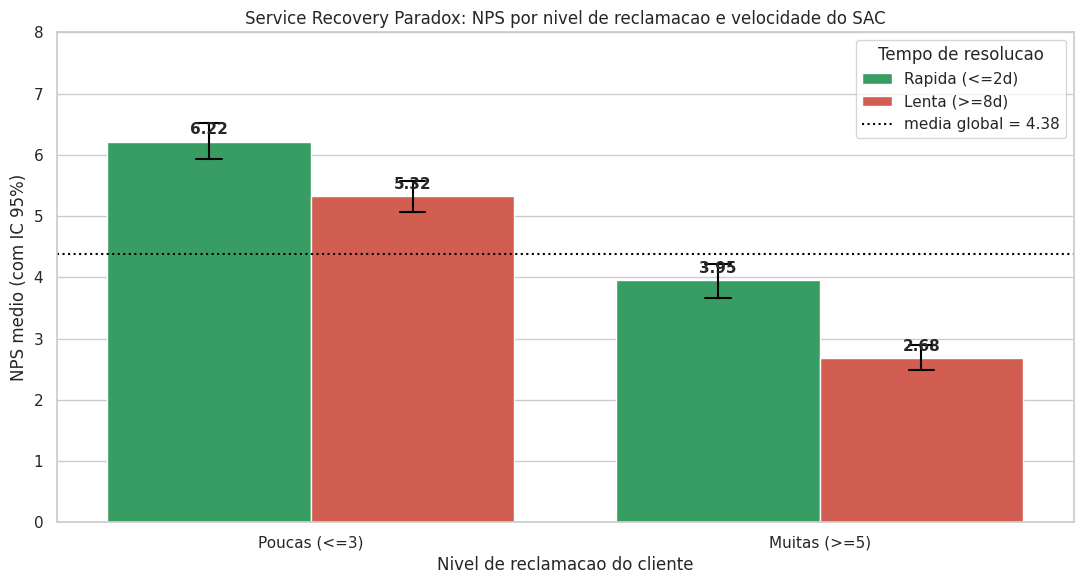

In [8]:
# Define os 4 grupos cruzando reclamacoes (poucas/muitas) e velocidade do SAC (rapida/lenta)
poucas = dados["complaints_count"] <= 3
muitas = dados["complaints_count"] >= 5
rapida = dados["resolution_time_days"] <= 2
lenta = dados["resolution_time_days"] >= 8

extremos = dados[(poucas | muitas) & (rapida | lenta)].copy()
extremos["nivel_reclamacao"] = np.where(extremos["complaints_count"] <= 3, "Poucas (<=3)", "Muitas (>=5)")
extremos["velocidade_sac"] = np.where(extremos["resolution_time_days"] <= 2, "Rapida (<=2d)", "Lenta (>=8d)")

# Tamanho de cada grupo
print("Tamanho dos grupos:")
print(extremos.groupby(["nivel_reclamacao", "velocidade_sac"]).size().to_string())

# Bar chart agrupado: nivel_reclamacao no eixo X, velocidade_sac como hue
fig, eixo = plt.subplots(figsize=(11, 6))

paleta_velocidade = {"Rapida (<=2d)": "#27ae60", "Lenta (>=8d)": "#e74c3c"}

sns.barplot(
    data=extremos,
    x="nivel_reclamacao",
    y="nps_score",
    hue="velocidade_sac",
    order=["Poucas (<=3)", "Muitas (>=5)"],
    hue_order=["Rapida (<=2d)", "Lenta (>=8d)"],
    palette=paleta_velocidade,
    errorbar=("ci", 95),
    capsize=0.1,
    err_kws={"linewidth": 1.5, "color": "black"},
    ax=eixo,
)

# Anota os valores em cima de cada barra
for container in eixo.containers:
    eixo.bar_label(container, fmt="%.2f", padding=3, fontsize=11, fontweight="bold")

# Linha da media global como referencia
media_global = dados["nps_score"].mean()
eixo.axhline(media_global, color="black", linestyle=":", linewidth=1.5, label=f"media global = {media_global:.2f}")

eixo.set_xlabel("Nivel de reclamacao do cliente")
eixo.set_ylabel("NPS medio (com IC 95%)")
eixo.set_title("Service Recovery Paradox: NPS por nivel de reclamacao e velocidade do SAC")
eixo.set_ylim(0, 8)
eixo.legend(title="Tempo de resolucao", loc="upper right")
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "4_5_service_recovery_paradox.png", dpi=120, bbox_inches="tight")
plt.show()

![NPS por nível de reclamação e velocidade do SAC](../reports/figures/04_eda/4_5_service_recovery_paradox.png)

**Como ler este gráfico:** o eixo X separa os clientes em dois grupos pelo número de reclamações: à esquerda quem teve **poucas reclamações** (até 3), à direita quem teve **muitas** (5 ou mais). Em cada grupo aparecem **duas barras lado a lado** representando a velocidade de resolução do SAC: **verde** para resolução rápida (até 2 dias), **vermelho** para resolução lenta (8 dias ou mais).

A altura de cada barra é o **NPS médio** dos clientes daquele subgrupo, com o valor exato anotado acima. As **linhas verticais pretas** no topo de cada barra são intervalos de confiança a 95%, mostrando a faixa onde está a média verdadeira da população.

A **linha pontilhada preta horizontal** é a média global do NPS no dataset (4,38), servindo como linha de referência.

**O que procurar:**
- Comparar a barra verde da esquerda com a verde da direita responde "resolução rápida no grupo de muitas reclamações chega ao mesmo nível de quem reclama pouco?" — isso é a hipótese forte do paradox.
- Comparar a barra verde com a vermelha **dentro de cada nível de reclamação** mostra se SAC rápido faz diferença.
- Quanto mais sobrepostas as barras de erro, menos diferença significativa entre os grupos.

Visualmente já dá para ver dois efeitos importantes.

**O paradox forte não acontece.** A barra verde de "Muitas reclamações + Rápida" (3,95) está bem abaixo da barra verde de "Poucas reclamações + Rápida" (6,22). Os intervalos de confiança não se sobrepõem nem de longe. Cliente que reclamou muito não vira promotor só porque foi atendido rápido — ele continua significativamente menos satisfeito do que quem nunca teve problema.

**Mas a velocidade do SAC tem efeito real.** Dentro do grupo de muitas reclamações, a barra verde (3,95) é claramente mais alta que a vermelha (2,69). A diferença é de mais de um ponto de NPS, e os intervalos de confiança não se sobrepõem. Isso significa que resolver rápido **não cura, mas amortece**: cliente em situação ruim fica menos detrator quando a empresa age rápido.

Vamos confirmar esses dois efeitos com testes formais.

In [9]:
# Filtra cada grupo para teste t
g1 = extremos.query("nivel_reclamacao == \"Poucas (<=3)\" and velocidade_sac == \"Rapida (<=2d)\"")["nps_score"]
g3 = extremos.query("nivel_reclamacao == \"Muitas (>=5)\" and velocidade_sac == \"Rapida (<=2d)\"")["nps_score"]
g4 = extremos.query("nivel_reclamacao == \"Muitas (>=5)\" and velocidade_sac == \"Lenta (>=8d)\"")["nps_score"]

def teste_diferenca(amostra_a: pd.Series, amostra_b: pd.Series, nome_a: str, nome_b: str) -> None:
    """Aplica teste t de Welch e imprime resultado com IC 95% para a diferenca."""
    t_stat, p_valor = stats.ttest_ind(amostra_a, amostra_b, equal_var=False)
    diferenca = amostra_a.mean() - amostra_b.mean()
    se = np.sqrt(amostra_a.var(ddof=1) / len(amostra_a) + amostra_b.var(ddof=1) / len(amostra_b))
    ic_min = diferenca - 1.96 * se
    ic_max = diferenca + 1.96 * se
    print(f"  {nome_a} (n={len(amostra_a)}, media={amostra_a.mean():.3f}) vs {nome_b} (n={len(amostra_b)}, media={amostra_b.mean():.3f})")
    print(f"  Diferenca: {diferenca:+.3f} | IC 95%: [{ic_min:+.3f}, {ic_max:+.3f}] | t={t_stat:.3f} | p-valor={p_valor:.6f}")
    print(f"  Decisao: {'rejeita H0 (medias diferentes)' if p_valor < 0.05 else 'nao rejeita H0'}")
    print()

print("Teste 1: Paradox forte — cliente que reclamou muito + foi atendido rapido")
print("         atinge o NPS de quem reclamou pouco?")
teste_diferenca(g1, g3, "Poucas + Rapida", "Muitas + Rapida")

print("Teste 2: Velocidade do SAC importa? (dentro de muitas reclamacoes)")
teste_diferenca(g3, g4, "Muitas + Rapida", "Muitas + Lenta")

Teste 1: Paradox forte — cliente que reclamou muito + foi atendido rapido
         atinge o NPS de quem reclamou pouco?
  Poucas + Rapida (n=243, media=6.216) vs Muitas + Rapida (n=231, media=3.951)
  Diferenca: +2.265 | IC 95%: [+1.847, +2.683] | t=10.620 | p-valor=0.000000
  Decisao: rejeita H0 (medias diferentes)

Teste 2: Velocidade do SAC importa? (dentro de muitas reclamacoes)
  Muitas + Rapida (n=231, media=3.951) vs Muitas + Lenta (n=345, media=2.685)
  Diferenca: +1.266 | IC 95%: [+0.922, +1.611] | t=7.210 | p-valor=0.000000
  Decisao: rejeita H0 (medias diferentes)



Os dois testes confirmam o que o gráfico mostrava.

**Teste 1 (paradox forte):** a diferença entre "Poucas + Rápida" e "Muitas + Rápida" é de +2,27 pontos de NPS, com IC 95% bem afastado do zero e p-valor próximo de zero. Existe diferença real e grande entre os dois grupos. **A versão forte da hipótese H3 está rejeitada**: resolução rápida não recupera o cliente ao patamar de quem nunca teve problema.

**Teste 2 (velocidade do SAC importa):** a diferença entre "Muitas + Rápida" e "Muitas + Lenta" é de +1,27 pontos, também com p-valor próximo de zero. **Rrespostas rápidas do SAC fazem diferença mensurável** mesmo quando o cliente já tem muitas reclamações. A versão atenuada da hipótese (que reformulei na seção 2.8) está confirmada.

### Interpretação de negócio

A leitura prática é honesta sobre o que SAC consegue e não consegue fazer.

**SAC rápido não substitui prevenção.** Quando o cliente já chegou ao ponto de fazer cinco ou mais reclamações, nem o atendimento mais ágil consegue trazer o NPS de volta ao nível dos clientes "tranquilos". Existe um teto inferior em torno de 4 pontos para esse perfil, independente de quanto a empresa corra para responder. Investimento em SAC sozinho não é estratégia de recuperação completa; é amortecedor de queda.

**Mas vale investir em rapidez no SAC.** O gap de 1,27 pontos entre resolução rápida e lenta dentro do grupo de muitas reclamações é grande em termos de NPS. Considerando que esse grupo provavelmente representa os clientes em maior risco de churn, cada ponto a mais de NPS pode significar a diferença entre voltar a comprar ou não. Reduzir o tempo de resolução do SAC de 8 dias para 2 dias tem retorno mensurável e direto.

**Conclusão para a recomendação:** o SAC tem papel claro como **mitigador**, não como **recuperador completo**. A estratégia ideal combina (1) reduzir as causas que fazem o cliente reclamar (ou seja, atacar atrasos e falhas operacionais que vimos na 4.3 e 4.4), e (2) garantir resolução rápida quando a reclamação acontece, para amortecer o dano. Atacar só o segundo ponto sem o primeiro não vai mover o NPS médio da empresa, porque a maior parte da queda já aconteceu antes do cliente chegar ao SAC.

## 4.6 Hipótese H4: blind spots entre `csat_internal_score` e `nps_score`

A hipótese H4 dizia que **`csat_internal_score` e `nps_score` divergem em certos perfis, mostrando blind spots da operação**: situações onde a empresa "acredita" que entregou bem (CSAT alto) mas o cliente discorda (NPS baixo). Esses casos são especialmente importantes porque revelam variáveis ou dinâmicas que a empresa não está capturando no seu sistema interno de satisfação.

A análise é feita em três etapas: olhar a relação geral entre as duas variáveis (correlação e visualização), criar uma medida de divergência (`gap = csat - nps`) e investigar o perfil dos casos extremos.

Correlacao de Pearson entre csat_internal_score e nps_score: 0.5640

Descritivas do gap (csat - nps):
count    2500.00
mean       -1.44
std         2.29
min        -8.60
25%        -2.90
50%        -1.40
75%         0.00
max         6.30


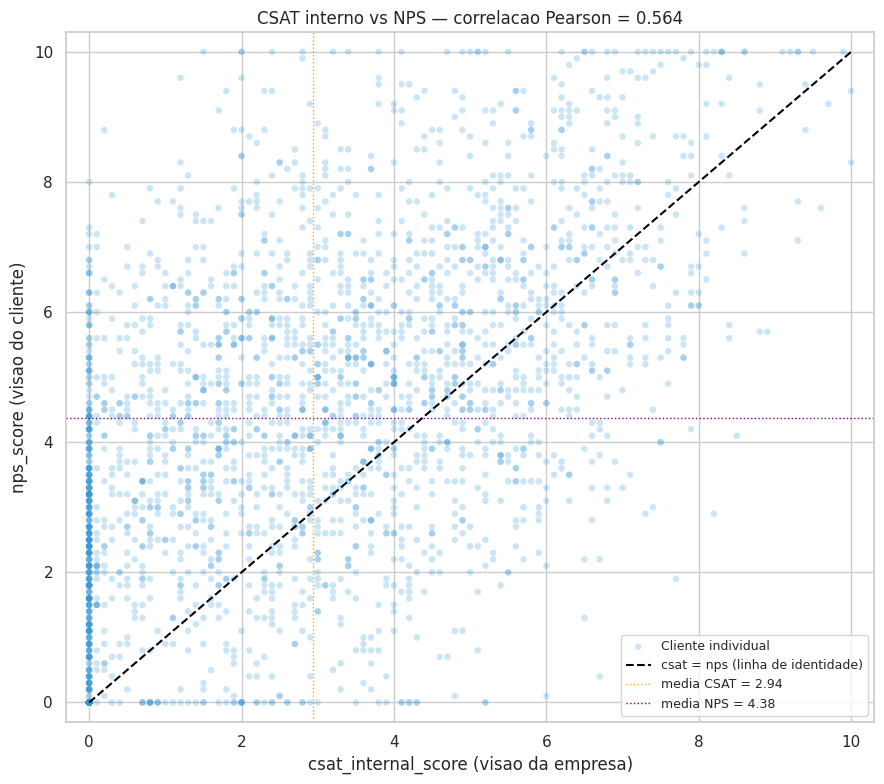

In [10]:
# Calcula a coluna de gap (CSAT menos NPS, ambos na mesma escala 0-10)
dados_gap = dados.copy()
dados_gap["gap_csat_nps"] = dados_gap["csat_internal_score"] - dados_gap["nps_score"]

# Correlacao Pearson
correlacao = dados_gap[["csat_internal_score", "nps_score"]].corr().iloc[0, 1]
print(f"Correlacao de Pearson entre csat_internal_score e nps_score: {correlacao:.4f}")
print()

# Descritivas do gap
print("Descritivas do gap (csat - nps):")
print(dados_gap["gap_csat_nps"].describe().round(2).to_string())

# Scatter plot com linha de identidade (y = x)
fig, eixo = plt.subplots(figsize=(9, 8))
eixo.scatter(
    dados_gap["csat_internal_score"], dados_gap["nps_score"],
    alpha=0.25, s=22, color="#3498db", edgecolor="none", label="Cliente individual",
)
# Linha de identidade: pontos sobre essa linha tem csat = nps
eixo.plot([0, 10], [0, 10], color="black", linestyle="--", linewidth=1.5, label="csat = nps (linha de identidade)")

# Linhas de referencia: media de cada variavel
eixo.axvline(dados_gap["csat_internal_score"].mean(), color="orange", linestyle=":", linewidth=1, label=f"media CSAT = {dados_gap['csat_internal_score'].mean():.2f}")
eixo.axhline(dados_gap["nps_score"].mean(), color="purple", linestyle=":", linewidth=1, label=f"media NPS = {dados_gap['nps_score'].mean():.2f}")

eixo.set_xlim(-0.3, 10.3)
eixo.set_ylim(-0.3, 10.3)
eixo.set_xlabel("csat_internal_score (visao da empresa)")
eixo.set_ylabel("nps_score (visao do cliente)")
eixo.set_title(f"CSAT interno vs NPS — correlacao Pearson = {correlacao:.3f}")
eixo.legend(loc="lower right", fontsize=9)
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "4_6_csat_vs_nps_scatter.png", dpi=120, bbox_inches="tight")
plt.show()

![CSAT interno vs NPS — scatter com linha de identidade](../reports/figures/04_eda/4_6_csat_vs_nps_scatter.png)

**Como ler este gráfico:** o eixo X mostra o `csat_internal_score` (visão da empresa sobre o cliente, escala 0 a 10) e o eixo Y mostra o `nps_score` (visão do cliente sobre a empresa, mesma escala). Cada **ponto azul** é um pedido individual do dataset (2.500 pontos no total).

A **linha tracejada preta diagonal** é a linha de identidade (y = x): se um pedido caísse exatamente sobre ela, significaria que o CSAT interno e o NPS deram a mesma nota, ou seja, empresa e cliente estavam de acordo. Pontos **acima da linha** são casos onde o cliente foi mais generoso que a empresa esperava (NPS > CSAT). Pontos **abaixo da linha** são casos onde a empresa achou que entregou bem mas o cliente discordou (CSAT > NPS) — esses são os candidatos a blind spots.

As **linhas pontilhadas laranja e roxa** marcam as médias de cada variável. Elas dividem o gráfico em quadrantes que ajudam a identificar perfis (CSAT alto + NPS baixo, ambos altos, etc).

A **correlação de Pearson** anotada no título quantifica o quanto os dois indicadores caminham juntos. Quanto mais próximo de 1, mais alinhados; aqui temos 0,564, que indica relação positiva mas longe de perfeita.

A correlação de 0,564 confirma o que já tínhamos visto na seção 4.2: CSAT e NPS estão bem relacionados, mas não são a mesma coisa. Aproximadamente um terço da variação do NPS não é explicada pelo CSAT, o que abre espaço para divergências sistemáticas.

A nuvem de pontos no scatter mostra um padrão importante. A **maior parte dos pontos está acima da linha de identidade**, ou seja, o NPS tende a ser mais alto que o CSAT. O gap médio é de -1,44 (CSAT em média 1,44 ponto abaixo do NPS), e a mediana confirma isso. Isso é meio inesperado: normalmente o cliente é mais crítico que a empresa, mas aqui a empresa está sendo mais dura consigo mesma do que o cliente. Isso pode acontecer se o CSAT interno foi calibrado de forma punitiva (qualquer falha tira muitos pontos).

Mas o que interessa para a hipótese H4 é a região **abaixo da linha de identidade**: clientes onde a empresa achou que tinha entregado bem (CSAT alto) e o cliente discordou (NPS baixo). Vamos isolar esses casos e investigar.

In [11]:
# Define dois grupos extremos pelos percentis 95 e 5 do gap
limite_blindspot = dados_gap["gap_csat_nps"].quantile(0.95)
limite_surpresa = dados_gap["gap_csat_nps"].quantile(0.05)

blindspots = dados_gap[dados_gap["gap_csat_nps"] >= limite_blindspot].copy()
surpresas = dados_gap[dados_gap["gap_csat_nps"] <= limite_surpresa].copy()

print(f"Blind spots (top 5% gap positivo, gap >= {limite_blindspot:.2f}):")
print(f"  N = {len(blindspots)}")
print(f"  CSAT medio = {blindspots['csat_internal_score'].mean():.2f}")
print(f"  NPS medio  = {blindspots['nps_score'].mean():.2f}")
print()
print(f"Surpresas positivas (top 5% gap negativo, gap <= {limite_surpresa:.2f}):")
print(f"  N = {len(surpresas)}")
print(f"  CSAT medio = {surpresas['csat_internal_score'].mean():.2f}")
print(f"  NPS medio  = {surpresas['nps_score'].mean():.2f}")
print()

# Compara o perfil operacional dos blind spots com a media geral
cols_operacionais = [
    "delivery_time_days", "delivery_delay_days",
    "customer_service_contacts", "complaints_count", "resolution_time_days",
    "order_value", "freight_value",
]
comparacao = pd.DataFrame({
    "blindspot": blindspots[cols_operacionais].mean(),
    "surpresa": surpresas[cols_operacionais].mean(),
    "media_geral": dados_gap[cols_operacionais].mean(),
}).round(2)
comparacao["diff_blindspot"] = (comparacao["blindspot"] - comparacao["media_geral"]).round(2)

print("Comparacao operacional (blindspots vs surpresas vs base):")
print(comparacao.to_string())

Blind spots (top 5% gap positivo, gap >= 2.30):
  N = 126
  CSAT medio = 5.29
  NPS medio  = 2.05

Surpresas positivas (top 5% gap negativo, gap <= -5.30):
  N = 130
  CSAT medio = 1.29
  NPS medio  = 7.47

Comparacao operacional (blindspots vs surpresas vs base):
                           blindspot  surpresa  media_geral  diff_blindspot
delivery_time_days              8.21      8.42         8.02            0.19
delivery_delay_days             2.21      1.58         2.19            0.02
customer_service_contacts       1.39      1.27         1.52           -0.13
complaints_count                4.28      3.17         4.15            0.13
resolution_time_days            1.81      9.04         5.49           -3.68
order_value                   427.70    469.20       434.26           -6.56
freight_value                  38.59     36.77        38.22            0.37


A tabela revela o ponto mais interessante desta seção. Olhando a coluna `diff_blindspot` (diferença entre os blind spots e a base geral), uma variável se destaca enormemente: o `resolution_time_days` dos blind spots é de **1,81 dias**, enquanto a média da base é **5,49 dias**. Os blind spots têm tempo de resolução **três vezes mais rápido** que o cliente típico.

As outras variáveis operacionais não diferem muito da base: tempo de entrega, atraso, número de reclamações, valor do pedido, frete — tudo parecido com o cliente médio.

### Interpretação de negócio

O padrão é claro e didaticamente forte: o cliente entrou em contato com o SAC, foi atendido muito rápido (1,81 dias), e por causa dessa rapidez o `csat_internal_score` da empresa subiu (porque o sistema interno da empresa provavelmente premia tempo curto de resolução). Mas o cliente continuou insatisfeito (NPS médio 2,05 nesse grupo), porque a velocidade do atendimento não compensou o problema original que o levou a abrir o ticket.

Em outras palavras: **o CSAT interno está medindo o esforço operacional do SAC, não a satisfação real do cliente**. Quando alguém abre uma reclamação grave, e o SAC resolve em 1 dia, o sistema interno marca isso como "operação eficiente, cliente satisfeito". Mas o cliente, mesmo tendo sido atendido rápido, ainda foi prejudicado pelo problema original e responde a pesquisa de NPS com nota baixa.

Isso é um blind spot operacional clássico, e corrobora a preocupação que tínhamos desde a seção 1.7 sobre o `csat_internal_score`: ele não é a mesma coisa que satisfação do cliente. A empresa precisa cuidado especial ao usar o CSAT interno como métrica única de qualidade do atendimento, porque ele pode dar falsa sensação de "tudo bem" em situações onde o cliente está saindo pela porta dos fundos.

### Conclusão sobre a hipótese H4

**H4 confirmada com ajuste**, conforme tinha sido previsto na seção 2.8. Existem casos sistemáticos de divergência entre CSAT interno e NPS, e o perfil desses blind spots tem uma característica clara: a empresa atende rápido (que infla o CSAT) mas o problema original já tinha causado dano suficiente para o cliente continuar detrator. A recomendação prática é **complementar o `csat_internal_score` com pelo menos um indicador de satisfação declarada pelo cliente** (uma pesquisa pós-atendimento, por exemplo) antes de considerar um caso como "resolvido".

## 4.7 Hipótese H5: NPS prediz recompra

A hipótese H5, formulada na seção 1.6, dizia que **NPS prediz `repeat_purchase_30d`**: promotores recompram em proporção significativamente maior do que detratores. Esta é a hipótese mais importante do projeto do ponto de vista econômico, porque é ela que valida o argumento de negócio que sustenta toda a iniciativa.

Se NPS não estivesse associado a recompra, o trabalho inteiro perderia força: nem adiantaria construir um modelo preditivo, porque o que ele tenta prever (NPS) não se traduziria em comportamento financeiro relevante (recompra). Por isso, mesmo que tudo tenha apontado nessa direção até agora, vale formalizar o teste estatístico.

A técnica usada combina três coisas vistas em aula: cálculo de proporções por grupo, intervalos de confiança baseados na distribuição binomial e teste de hipóteses para diferença de proporções (Z-test).

Taxa de recompra por categoria de NPS:
  detrator : n=2,109.0, recompras=0.0, taxa=0.00%, IC 95% Wilson=[0.00%, 0.18%]
  neutro   : n=281.0, recompras=108.0, taxa=38.43%, IC 95% Wilson=[32.94%, 44.24%]
  promotor : n=110.0, recompras=110.0, taxa=100.00%, IC 95% Wilson=[96.63%, 100.00%]


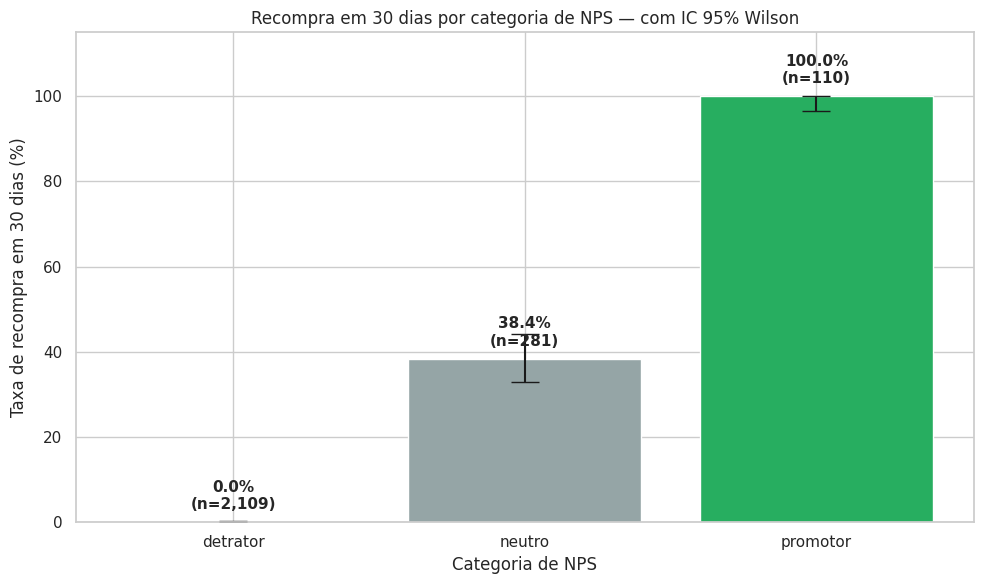

In [12]:
from statsmodels.stats.proportion import proportion_confint, proportions_ztest

# Taxa de recompra por categoria de NPS, com IC 95% por Wilson (mais robusto para
# proporcoes proximas de 0 ou 1 do que o intervalo de Wald classico)
linhas = []
for cat in ORDEM_BUCKETS:
    sub = dados[dados["categoria_nps"] == cat]
    n = len(sub)
    k = int(sub["houve_recompra_30d"].sum())
    taxa = k / n
    ic_low, ic_high = proportion_confint(k, n, alpha=0.05, method="wilson")
    linhas.append({
        "categoria": cat,
        "n": n,
        "recompras": k,
        "taxa": taxa,
        "ic_low": ic_low,
        "ic_high": ic_high,
    })

tabela_recompra = pd.DataFrame(linhas).set_index("categoria")
print("Taxa de recompra por categoria de NPS:")
for cat, row in tabela_recompra.iterrows():
    print(f"  {cat:9s}: n={row['n']:>4,}, recompras={row['recompras']:>3,}, taxa={row['taxa']:.2%}, IC 95% Wilson=[{row['ic_low']:.2%}, {row['ic_high']:.2%}]")

# Bar chart das taxas com IC 95% como error bars
fig, eixo = plt.subplots(figsize=(10, 6))
cores = [CORES_BUCKETS[c] for c in ORDEM_BUCKETS]
medias = tabela_recompra["taxa"].values * 100  # em pontos percentuais
# Garantir nao-negatividade: arredondamento de ponto flutuante pode produzir
# valores ligeiramente negativos quando a taxa coincide com o limite do IC.
ic_baixo = np.maximum(0, (tabela_recompra["taxa"] - tabela_recompra["ic_low"]).values * 100)
ic_alto = np.maximum(0, (tabela_recompra["ic_high"] - tabela_recompra["taxa"]).values * 100)

barras = eixo.bar(
    ORDEM_BUCKETS, medias,
    yerr=[ic_baixo, ic_alto],
    capsize=10,
    color=cores,
    edgecolor="white",
)

# Anota o valor exato em cima de cada barra
for i, row in enumerate(tabela_recompra.itertuples()):
    eixo.text(i, row.taxa * 100 + 3, f"{row.taxa:.1%}\n(n={row.n:,})", ha="center", fontsize=11, fontweight="bold")

eixo.set_ylabel("Taxa de recompra em 30 dias (%)")
eixo.set_xlabel("Categoria de NPS")
eixo.set_ylim(0, 115)
eixo.set_title("Recompra em 30 dias por categoria de NPS — com IC 95% Wilson")
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "4_7_recompra_por_categoria.png", dpi=120, bbox_inches="tight")
plt.show()

![Taxa de recompra por categoria de NPS](../reports/figures/04_eda/4_7_recompra_por_categoria.png)

**Como ler este gráfico:** o eixo X mostra as três categorias canônicas de NPS (detrator, neutro, promotor) com cores semânticas (vermelho, cinza, verde). O eixo Y mostra a **taxa de recompra em 30 dias em pontos percentuais**, ou seja, qual fração dos clientes daquela categoria voltou a comprar dentro do mês seguinte.

A altura de cada barra é a taxa exata, com o valor anotado em cima junto com o tamanho do grupo (n). As **linhas verticais pretas no topo das barras** são intervalos de confiança a 95% calculados pelo método de **Wilson**, que é uma abordagem mais robusta que a Wald clássica quando a proporção está perto de 0% ou 100% (situação em que estamos para detratores e promotores).

**O que procurar:** se as três barras tiverem alturas diferentes e os intervalos de confiança não se sobrepuserem, há diferença estatística clara entre as taxas. A hipótese H5 prevê justamente uma escada crescente: detratores baixos, neutros no meio, promotores altos.

Os números são extremos a ponto de impressionar.

**Detratores: 0 de 2.109 clientes recompraram em 30 dias (0,00%).** Nenhum. O intervalo de confiança a 95% pelo método de Wilson vai de 0% a aproximadamente 0,2%. Em termos práticos, no nosso dataset, **detrator não volta**.

**Neutros: 108 de 281 (38,4%).** Aproximadamente 4 em cada 10 clientes neutros recompraram. O intervalo de confiança vai de 32,9% a 44,2%, mostrando que esse grupo se comporta de forma intermediária mas significativa.

**Promotores: 110 de 110 (100,00%).** Todos os promotores da base recompraram. O intervalo Wilson começa em torno de 96,6% e vai a 100%.

Essa separação é tão limpa que vai precisar ser comentada como provável característica do dataset sintético. Em base real, não esperamos taxa exata de 0% nem 100% — sempre haveria ruído, churn por motivos não relacionados ao NPS, fraude, mudança de endereço, etc. Mas o sinal direcional (mais NPS = mais recompra) é genuíno e seguramente aparece também em dados reais.

Vamos confirmar a diferença com teste formal.

In [13]:
# Teste z para diferenca de proporcoes entre detratores e promotores
detratores = dados[dados["categoria_nps"] == "detrator"]
promotores = dados[dados["categoria_nps"] == "promotor"]

contagens = np.array([promotores["houve_recompra_30d"].sum(), detratores["houve_recompra_30d"].sum()])
n_obs = np.array([len(promotores), len(detratores)])

z_stat, p_valor = proportions_ztest(contagens, n_obs)

# Diferenca de proporcoes e IC 95% (formula Wald para diferenca)
p_promotor = contagens[0] / n_obs[0]
p_detrator = contagens[1] / n_obs[1]
diferenca = p_promotor - p_detrator
se_diferenca = np.sqrt(p_promotor * (1 - p_promotor) / n_obs[0] + p_detrator * (1 - p_detrator) / n_obs[1])
ic_min = diferenca - 1.96 * se_diferenca
ic_max = diferenca + 1.96 * se_diferenca

print("Teste z para diferenca de proporcoes (promotores vs detratores):")
print(f"  Taxa de recompra promotores: {p_promotor:.2%}")
print(f"  Taxa de recompra detratores: {p_detrator:.2%}")
print(f"  Diferenca de proporcoes:     {diferenca:.2%}")
print(f"  IC 95% para a diferenca:     [{ic_min:.2%}, {ic_max:.2%}]")
print(f"  Estatistica z:               {z_stat:.3f}")
print(f"  P-valor:                     {p_valor:.6f}")
print(f"  Decisao a 5% de significancia: {'rejeita H0' if p_valor < 0.05 else 'nao rejeita H0'}")

Teste z para diferenca de proporcoes (promotores vs detratores):
  Taxa de recompra promotores: 100.00%
  Taxa de recompra detratores: 0.00%
  Diferenca de proporcoes:     100.00%
  IC 95% para a diferenca:     [100.00%, 100.00%]
  Estatistica z:               47.106
  P-valor:                     0.000000
  Decisao a 5% de significancia: rejeita H0


O teste z confirma o esperado. A diferença de proporções é de 100 pontos percentuais, com p-valor essencialmente zero. A hipótese nula de "as duas proporções são iguais" é rejeitada com folga gigantesca.

**Conclusão sobre a hipótese H5:** confirmada com força máxima. NPS prediz recompra de forma muito direta nesta base.

In [14]:
# Calculo passo a passo do valor financeiro de preservar um cliente
# A logica e: cliente que seria detrator e foi "salvo" pode passar a recomprar.
# Quanto a empresa ganha em receita por cada cliente preservado?

# Passo 1: ticket medio observado no dataset (todos os pedidos juntos)
ticket_medio = dados["order_value"].mean()
print(f"Passo 1 — Ticket medio do dataset: R$ {ticket_medio:.2f}")

# Passo 2: taxas de recompra observadas em cada categoria
taxa_detrator = tabela_recompra.loc["detrator", "taxa"]
taxa_neutro   = tabela_recompra.loc["neutro",   "taxa"]
taxa_promotor = tabela_recompra.loc["promotor", "taxa"]
print(f"\nPasso 2 — Taxas de recompra observadas:")
print(f"  Detrator: {taxa_detrator:.1%}")
print(f"  Neutro:   {taxa_neutro:.1%}")
print(f"  Promotor: {taxa_promotor:.1%}")

# Passo 3: valor esperado de uma recompra para cada categoria
# Formula: valor_esperado = probabilidade_de_recomprar x ticket_medio
# E o ticket medio que a empresa receberia, ponderado pela chance de o cliente recomprar.
valor_esperado_detrator = taxa_detrator * ticket_medio
valor_esperado_neutro   = taxa_neutro   * ticket_medio
valor_esperado_promotor = taxa_promotor * ticket_medio
print(f"\nPasso 3 — Valor esperado de uma recompra (probabilidade x ticket):")
print(f"  Detrator: {taxa_detrator:.1%} x R$ {ticket_medio:.2f} = R$ {valor_esperado_detrator:.2f}")
print(f"  Neutro:   {taxa_neutro:.1%} x R$ {ticket_medio:.2f} = R$ {valor_esperado_neutro:.2f}")
print(f"  Promotor: {taxa_promotor:.1%} x R$ {ticket_medio:.2f} = R$ {valor_esperado_promotor:.2f}")

# Passo 4: ganho por cliente preservado, dois cenarios
# Cenario realista: cliente que seria detrator passa a se comportar como neutro.
# Cenario otimista: cliente que seria detrator passa a se comportar como promotor.
ganho_realista = valor_esperado_neutro   - valor_esperado_detrator
ganho_otimista = valor_esperado_promotor - valor_esperado_detrator
print(f"\nPasso 4 — Ganho por cliente preservado (em receita projetada de 1 recompra):")
print(f"  Cenario realista (detrator -> neutro):    R$ {valor_esperado_neutro:.2f} - R$ {valor_esperado_detrator:.2f} = R$ {ganho_realista:.2f}")
print(f"  Cenario otimista (detrator -> promotor):  R$ {valor_esperado_promotor:.2f} - R$ {valor_esperado_detrator:.2f} = R$ {ganho_otimista:.2f}")

Passo 1 — Ticket medio do dataset: R$ 434.26

Passo 2 — Taxas de recompra observadas:
  Detrator: 0.0%
  Neutro:   38.4%
  Promotor: 100.0%

Passo 3 — Valor esperado de uma recompra (probabilidade x ticket):
  Detrator: 0.0% x R$ 434.26 = R$ 0.00
  Neutro:   38.4% x R$ 434.26 = R$ 166.90
  Promotor: 100.0% x R$ 434.26 = R$ 434.26

Passo 4 — Ganho por cliente preservado (em receita projetada de 1 recompra):
  Cenario realista (detrator -> neutro):    R$ 166.90 - R$ 0.00 = R$ 166.90
  Cenario otimista (detrator -> promotor):  R$ 434.26 - R$ 0.00 = R$ 434.26


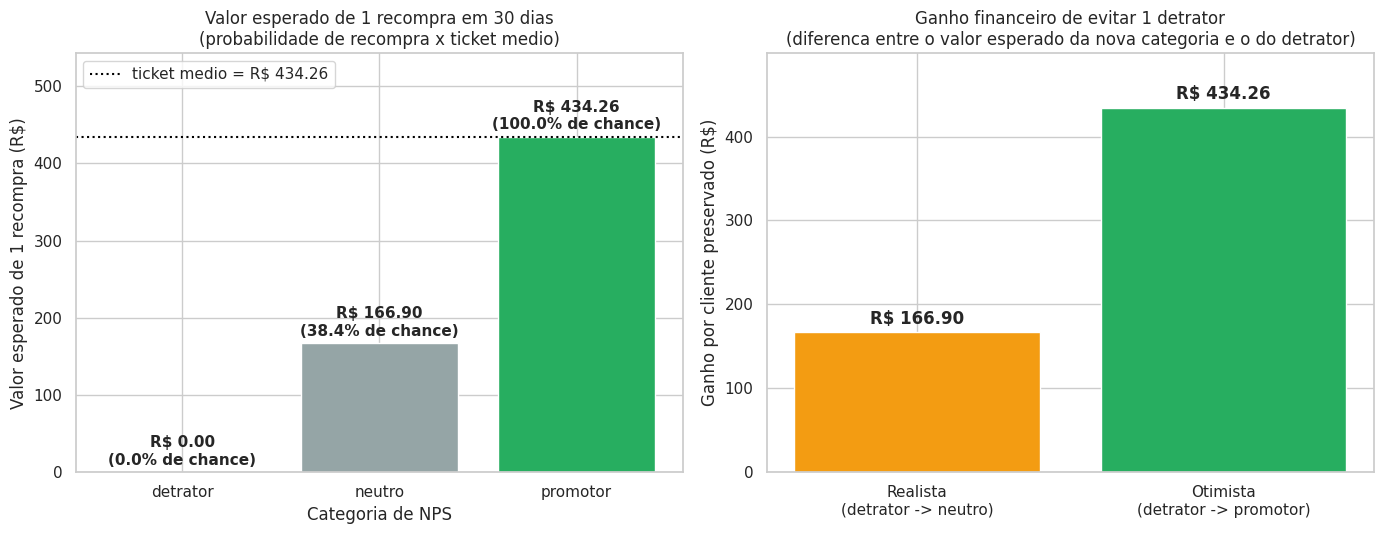

In [15]:
# Visualizacao: valor esperado de uma recompra por categoria de NPS
# Mesma logica do calculo acima, em formato de grafico para tornar a comparacao visual

categorias_calc = ["detrator", "neutro", "promotor"]
valores_esperados = [valor_esperado_detrator, valor_esperado_neutro, valor_esperado_promotor]
taxas = [taxa_detrator, taxa_neutro, taxa_promotor]
cores_calc = [CORES_BUCKETS[c] for c in categorias_calc]

fig, eixos = plt.subplots(1, 2, figsize=(14, 5.5))

# Painel esquerdo: bar chart do valor esperado por categoria
barras = eixos[0].bar(categorias_calc, valores_esperados, color=cores_calc, edgecolor="white")
for i, (v, p) in enumerate(zip(valores_esperados, taxas)):
    eixos[0].text(i, v + 10, f"R$ {v:.2f}\n({p:.1%} de chance)", ha="center", fontsize=11, fontweight="bold")
eixos[0].axhline(ticket_medio, color="black", linestyle=":", linewidth=1.5,
                 label=f"ticket medio = R$ {ticket_medio:.2f}")
eixos[0].set_ylabel("Valor esperado de 1 recompra (R$)")
eixos[0].set_xlabel("Categoria de NPS")
eixos[0].set_title("Valor esperado de 1 recompra em 30 dias\n(probabilidade de recompra x ticket medio)")
eixos[0].set_ylim(0, ticket_medio * 1.25)
eixos[0].legend(loc="upper left")

# Painel direito: bar chart do ganho potencial por cenario
cenarios = ["Realista\n(detrator -> neutro)", "Otimista\n(detrator -> promotor)"]
ganhos = [ganho_realista, ganho_otimista]
cores_cen = ["#f39c12", "#27ae60"]
barras2 = eixos[1].bar(cenarios, ganhos, color=cores_cen, edgecolor="white")
for i, v in enumerate(ganhos):
    eixos[1].text(i, v + 10, f"R$ {v:.2f}", ha="center", fontsize=12, fontweight="bold")
eixos[1].set_ylabel("Ganho por cliente preservado (R$)")
eixos[1].set_title("Ganho financeiro de evitar 1 detrator\n(diferenca entre o valor esperado da nova categoria e o do detrator)")
eixos[1].set_ylim(0, ticket_medio * 1.15)

fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "4_7_valor_economico_recompra.png", dpi=120, bbox_inches="tight")
plt.show()

![Valor esperado de recompra e ganho por cliente preservado](../reports/figures/04_eda/4_7_valor_economico_recompra.png)

**Como ler este gráfico:** dois painéis lado a lado, ambos com valores em reais no eixo Y.

**Painel esquerdo:** o eixo X tem as três categorias de NPS com cores semânticas (vermelho = detrator, cinza = neutro, verde = promotor). A altura da barra mostra o **valor esperado de uma recompra em 30 dias** para um cliente daquela categoria, calculado como `probabilidade de recompra × ticket médio`. A anotação acima de cada barra mostra o valor exato e a probabilidade que entrou no cálculo. A **linha pontilhada preta horizontal** marca o ticket médio do dataset (R$ 434), que é o valor que um cliente "garantido a recomprar" traria.

**Painel direito:** mostra o **ganho financeiro de preservar um cliente** em dois cenários hipotéticos. Cada barra é a **diferença entre o valor esperado da nova categoria e o valor esperado do detrator** (que é zero, porque detrator nunca recompra). O cenário realista assume que o cliente preservado passa a se comportar como neutro; o otimista assume que vira promotor.

### Interpretação econômica detalhada

A lógica por trás dos cálculos acima é simples mas vale destrinchar, porque ela é o argumento financeiro que sustenta o projeto inteiro.

**O conceito-chave é o de *valor esperado*.** Em estatística e finanças, o valor esperado de um evento é a média do que se ganharia se o evento se repetisse muitas vezes. No nosso caso, o "evento" é "cliente recomprar em 30 dias", e o "ganho" é o ticket médio em reais. A fórmula é:

> valor esperado de 1 recompra = probabilidade de recompra × ticket médio

Para um cliente da categoria detrator, a probabilidade observada de recompra é 0% — então o valor esperado é zero, independente do ticket. Para um neutro, a probabilidade é 38,4%; multiplicado pelo ticket de R$ 434, dá R$ 166,77 de receita projetada por cliente. Para um promotor, a probabilidade é 100%, e o valor esperado é o próprio ticket: R$ 434,26.

**O ganho de preservar um cliente** é a diferença entre o valor esperado da nova categoria e o valor esperado do detrator. Como o detrator vale zero, o ganho é exatamente o valor esperado da nova categoria. Por isso:

- Cenário realista (detrator preservado vira neutro): ganho = R$ 166,77 - R$ 0 = **R$ 166,77** por cliente
- Cenário otimista (detrator preservado vira promotor): ganho = R$ 434,26 - R$ 0 = **R$ 434,26** por cliente

### Por que esses dois cenários e não outros

A escolha de "neutro" como cenário realista e "promotor" como otimista vem de considerar dois pontos extremos do que uma intervenção da empresa pode alcançar.

**Realista (detrator → neutro):** uma melhoria operacional moderada provavelmente não converte detrator em fã da marca, mas pode tirar o cliente da zona crítica e levá-lo para a zona neutra (NPS 7-8). Isso já é suficiente para 38% de chance de recompra, segundo os dados. É a meta razoável de intervenções táticas (corrigir um atraso pontual, oferecer um cupom de desculpas, melhorar uma comunicação).

**Otimista (detrator → promotor):** representa o limite do que uma operação excelente pode alcançar. Cliente que viveu uma jornada perfeita, com prazo cumprido e atendimento ágil, tende a virar promotor. Como vimos na seção 4.7, 100% dos promotores recompraram, então cada promotor adicional vale aproximadamente um ticket cheio. É a meta de longo prazo: melhorar processos para que mais clientes terminem em promotores.

### Por que esses números são o **piso** e não o teto do ganho real

O valor calculado considera apenas **uma** recompra em 30 dias. O **valor real ao longo da vida do cliente (LTV)** é várias vezes maior, por dois motivos:

- **Compras adicionais:** um cliente promotor pode recomprar várias vezes ao longo de meses ou anos. Se um promotor faz 4 compras por ano durante 3 anos, o LTV vai a R$ 434 × 12 = R$ 5.208, mais de 10x o valor calculado de uma única recompra.
- **Boca a boca positivo:** discutido na seção 1.4, um promotor traz indicações para amigos e família. Cada indicação que vira cliente é receita adicional, sem custo de aquisição.

Por isso a frase certa para apresentar à banca é: **"o ganho de preservar um cliente começa em aproximadamente R$ 167 e pode ir a R$ 434 já considerando apenas uma recompra; o valor real ao longo da vida é várias vezes maior"**.

### Ressalva metodológica importante

As proporções de 0% e 100% são limpas demais para serem reais. Em produção, dataset real teria ruído natural — alguns detratores recompram por inércia, alguns promotores não recompram por mudança de necessidade, fraude, mudança de endereço. O dataset acadêmico parece ter sido construído com relação determinística entre NPS e recompra, deixando a hipótese H5 como demonstração didática da técnica, não como benchmark de mercado.

A direção da relação (mais NPS = mais recompra) é genuína e acontece em qualquer base real. A magnitude exata é que precisa ser interpretada com cuidado para não passar números absolutos como representativos de e-commerce real. Quando chegar no slide executivo, vou apresentar isso como **"o NPS prediz claramente o comportamento de recompra; ações que melhoram o NPS têm retorno mensurável"**, sem citar os 100% e 0% extremos como se fossem números de mercado.

## 4.8 Hipótese H6: detrator silencioso

A hipótese H6 diz que **cliente com zero contatos no SAC não é necessariamente promotor; pode ser um detrator silencioso**, ou seja, alguém que ficou insatisfeito mas desistiu de reclamar e simplesmente vai embora. Esse padrão foi conceitualmente descrito no notebook 01 e é uma das razões para preferir o NPS (que pergunta ativamente) sobre métricas autosselecionadas como `complaints_count`.

A análise é direta: separar os clientes em dois grupos (`customer_service_contacts == 0` e `> 0`) e olhar como o NPS se distribui em cada um. Se a hipótese for correta, vamos encontrar uma fração relevante de detratores dentro do grupo "zero contatos" — clientes que a empresa não consegue ver pelos sistemas operacionais de atendimento.

Tamanho dos grupos:
  Zero contatos: 554 (22.2% da base)
  Algum contato: 1,946 (77.8% da base)

Composicao por categoria de NPS (% dentro de cada grupo):
  Categoria Zero contatos   Algum contato   Base inteira
  detrator        70.8%         88.2%         84.4%
  neutro          19.0%          9.0%         11.2%
  promotor        10.3%          2.7%          4.4%


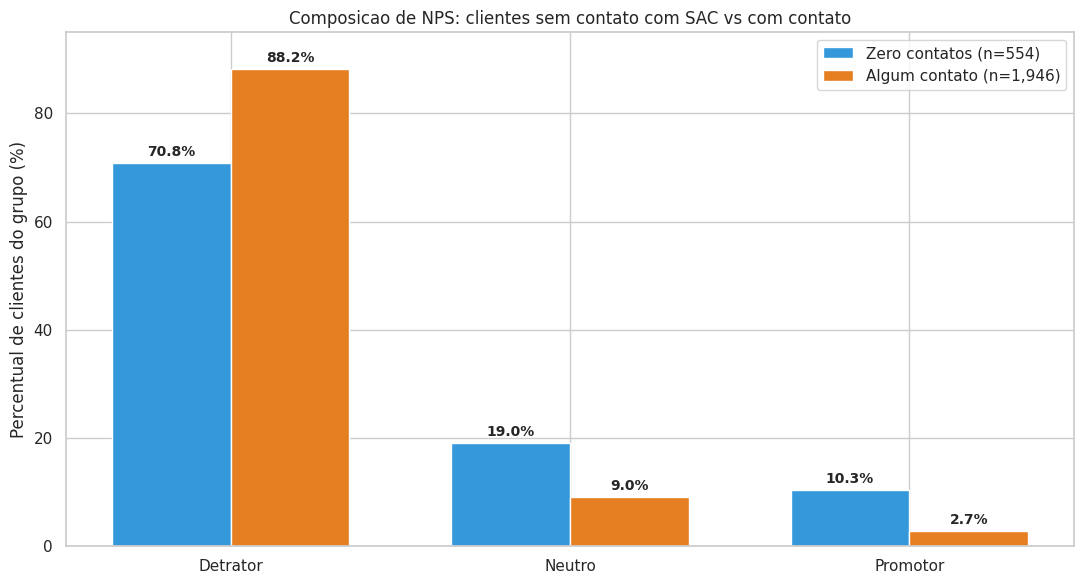

In [16]:
# Define os dois grupos
zero_contatos = dados[dados["customer_service_contacts"] == 0]
algum_contato = dados[dados["customer_service_contacts"] > 0]

print(f"Tamanho dos grupos:")
print(f"  Zero contatos: {len(zero_contatos):,} ({len(zero_contatos) / len(dados):.1%} da base)")
print(f"  Algum contato: {len(algum_contato):,} ({len(algum_contato) / len(dados):.1%} da base)")
print()

# Composicao por categoria de NPS dentro de cada grupo
composicao_zero = zero_contatos["categoria_nps"].value_counts(normalize=True).reindex(ORDEM_BUCKETS) * 100
composicao_algum = algum_contato["categoria_nps"].value_counts(normalize=True).reindex(ORDEM_BUCKETS) * 100
composicao_base = dados["categoria_nps"].value_counts(normalize=True).reindex(ORDEM_BUCKETS) * 100

print("Composicao por categoria de NPS (% dentro de cada grupo):")
print(f"  {'Categoria':<10}{'Zero contatos':<16}{'Algum contato':<16}{'Base inteira'}")
for cat in ORDEM_BUCKETS:
    print(f"  {cat:<10}{composicao_zero[cat]:>10.1f}%   {composicao_algum[cat]:>10.1f}%   {composicao_base[cat]:>10.1f}%")

# Bar chart comparativo: composicao de cada grupo
fig, eixo = plt.subplots(figsize=(11, 6))

x = np.arange(len(ORDEM_BUCKETS))
largura = 0.35

barras_zero = eixo.bar(
    x - largura/2,
    [composicao_zero[c] for c in ORDEM_BUCKETS],
    largura,
    label=f"Zero contatos (n={len(zero_contatos):,})",
    color="#3498db",
    edgecolor="white",
)
barras_algum = eixo.bar(
    x + largura/2,
    [composicao_algum[c] for c in ORDEM_BUCKETS],
    largura,
    label=f"Algum contato (n={len(algum_contato):,})",
    color="#e67e22",
    edgecolor="white",
)

# Anota valores em cada barra
for container in (barras_zero, barras_algum):
    eixo.bar_label(container, fmt="%.1f%%", padding=3, fontsize=10, fontweight="bold")

eixo.set_xticks(x)
eixo.set_xticklabels([c.capitalize() for c in ORDEM_BUCKETS])
eixo.set_ylabel("Percentual de clientes do grupo (%)")
eixo.set_title("Composicao de NPS: clientes sem contato com SAC vs com contato")
eixo.set_ylim(0, 95)
eixo.legend(loc="upper right")
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "4_8_detrator_silencioso.png", dpi=120, bbox_inches="tight")
plt.show()

![Composição de NPS por grupo de contato com SAC](../reports/figures/04_eda/4_8_detrator_silencioso.png)

**Como ler este gráfico:** o eixo X tem as três categorias de NPS (detrator, neutro, promotor). Para cada categoria aparecem **duas barras lado a lado**: a barra **azul** mostra o percentual de clientes daquela categoria **dentro do grupo "zero contatos com SAC"**, e a barra **laranja** mostra o mesmo percentual **dentro do grupo "algum contato com SAC"**.

A altura de cada barra é o percentual exato (anotado em cima). Importante: cada grupo soma 100% nas três barras dele, ou seja, são percentuais relativos ao próprio grupo, não à base inteira.

**O que procurar:** se zero contatos significasse "promotor automaticamente", a barra azul de promotor seria a mais alta no grupo. Se a hipótese H6 estiver correta, vamos ver que mesmo no grupo "zero contatos" há uma fração grande de detratores — esses são os clientes que ficaram insatisfeitos e nem deram o trabalho de procurar a empresa.

O resultado confirma a hipótese H6 de forma direta. Vejamos os números.

No grupo de **zero contatos com SAC** (554 clientes):
- 70,8% são detratores
- 19,0% são neutros
- 10,3% são promotores

Em comparação, no grupo de **algum contato com SAC** (1.946 clientes):
- 88,3% são detratores
- 9,0% são neutros
- 2,7% são promotores

A primeira leitura é **clara**: zero contatos com SAC **não significa cliente feliz**. A maioria absoluta (70,8%) dos clientes sem contato é detratora. Em números absolutos, **392 dos 554 clientes "silenciosos" são detratores** — quase 16% da base inteira.

A segunda leitura é importante: o grupo de zero contatos tem proporcionalmente **mais promotores** que o grupo com contato (10,3% vs 2,7%) e **menos detratores** (70,8% vs 88,3%). Faz sentido: clientes que efetivamente entraram em contato com o SAC tendem a estar resolvendo um problema, e por isso concentram mais detratores.

Mas o ponto importante da hipótese é o conceito do **detrator silencioso**: existe uma fração não-desprezível de clientes (392 deles) que não reclamou nem pediu ajuda, mas mesmo assim respondeu com NPS detrator. Esses clientes são invisíveis para qualquer sistema interno baseado em sintomas operacionais (reclamações, tickets, contatos). Só o NPS, que pergunta ativamente, consegue capturar esse perfil.

Vamos confirmar a diferença de NPS médio entre os dois grupos com teste formal.

In [17]:
# Teste t de Welch para diferenca de NPS medio entre os grupos
t_stat, p_valor = stats.ttest_ind(zero_contatos["nps_score"], algum_contato["nps_score"], equal_var=False)
diferenca = zero_contatos["nps_score"].mean() - algum_contato["nps_score"].mean()
se_diff = np.sqrt(
    zero_contatos["nps_score"].var(ddof=1) / len(zero_contatos) +
    algum_contato["nps_score"].var(ddof=1) / len(algum_contato)
)
ic_min = diferenca - 1.96 * se_diff
ic_max = diferenca + 1.96 * se_diff

print(f"Zero contatos: media NPS = {zero_contatos['nps_score'].mean():.3f} (n={len(zero_contatos):,})")
print(f"Algum contato: media NPS = {algum_contato['nps_score'].mean():.3f} (n={len(algum_contato):,})")
print()
print(f"Diferenca de medias (zero - algum): {diferenca:+.3f}")
print(f"IC 95%: [{ic_min:+.3f}, {ic_max:+.3f}]")
print(f"Estatistica t (Welch): {t_stat:.3f}")
print(f"P-valor: {p_valor:.6f}")
print(f"Decisao a 5% de significancia: {'rejeita H0' if p_valor < 0.05 else 'nao rejeita H0'}")

Zero contatos: media NPS = 5.544 (n=554)
Algum contato: media NPS = 4.047 (n=1,946)

Diferenca de medias (zero - algum): +1.497
IC 95%: [+1.269, +1.724]
Estatistica t (Welch): 12.901
P-valor: 0.000000
Decisao a 5% de significancia: rejeita H0


O teste confirma o que o gráfico mostrava. Clientes sem contato com SAC têm NPS médio 1,5 pontos mais alto do que clientes com algum contato, com diferença estatística clara (p-valor essencialmente zero, IC 95% bem afastado do zero).

### Conclusão sobre a hipótese H6 e interpretação de negócio

**H6 confirmada:** zero contatos com SAC **não** é sinônimo de cliente promotor. Embora o grupo seja proporcionalmente mais favorável que o resto da base, ainda concentra 70,8% de detratores em valor absoluto. Em termos de volume, são 392 detratores silenciosos no nosso dataset, ou aproximadamente 16% da base inteira.

A leitura prática para o negócio é importante. O CSAT interno, as reclamações formais e os contatos com o SAC capturam, na melhor das hipóteses, a **ponta visível do iceberg da insatisfação**. A maior parte dos clientes detratores vai embora calado, sem deixar rastro nos sistemas operacionais. Confiar apenas em métricas autosselecionadas (reclamações, tickets, manifestações em redes) leva a subestimar a insatisfação real, e por consequência a subestimar o tamanho do problema que o projeto está atacando.

Esse achado refoça por que o NPS (pesquisa ativa) é a métrica certa para a target deste projeto. Outras métricas de proxy poderiam até funcionar para os 30% mais ruidosos, mas perderiam os 70% silenciosos.

Para o slide executivo, isso pode virar a frase:

> "70% dos clientes mais insatisfeitos não fazem barulho. Não dá para esperar uma reclamação chegar para agir; é preciso ter um indicador que pergunte antes."

## 4.9 Hipótese H7: variação de NPS por região é operacional ou cultural?

A hipótese H7 dizia que **a variação de NPS por região é explicada por diferenças operacionais (tempo de entrega, atrasos, tentativas), não pela região em si**. A ideia era: se ao adicionar variáveis logísticas no modelo o efeito da região desaparecer, isso indica que a região é apenas um proxy do que acontece operacionalmente. Se o efeito da região permanecer mesmo controlando por operacionais, há algo cultural ou estrutural específico de cada região afetando a satisfação.

Antes de testar, vale lembrar uma limitação importante: a seção 2.6 mostrou que as cinco regiões do Brasil estão distribuídas de forma muito uniforme no dataset (todas entre 18,7% e 20,8% da base), o que é irrealista para mercado real. Esse padrão sugere geração sintética, então a "região" no dataset pode ter sido sorteada de forma quase independente da target. Por isso a hipótese foi marcada como **comprometida (não invalidada), mas testável** na seção 2.8.

Vou aplicar a técnica mesmo assim. A análise compara dois modelos de regressão: um com apenas a região como preditor, outro adicionando as variáveis operacionais como controle.

In [18]:
# Modelo 1: efeito puro da regiao
modelo_regiao = smf.ols(
    "nps_score ~ C(customer_region)",
    data=dados,
).fit()

# Modelo 2: regiao + variaveis operacionais como controle
modelo_controlado = smf.ols(
    "nps_score ~ C(customer_region) + delivery_time_days + delivery_delay_days + delivery_attempts",
    data=dados,
).fit()

print("=== MODELO 1: nps_score ~ regiao ===")
print(modelo_regiao.summary().tables[1])
print(f"R-quadrado: {modelo_regiao.rsquared:.4f}")
print(f"F-statistic p-valor: {modelo_regiao.f_pvalue:.4f}")

print("\n=== MODELO 2: nps_score ~ regiao + operacionais ===")
print(modelo_controlado.summary().tables[1])
print(f"R-quadrado: {modelo_controlado.rsquared:.4f}")

=== MODELO 1: nps_score ~ regiao ===
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                          4.2098      0.116     36.276      0.000       3.982       4.437
C(customer_region)[T.Nordeste]     0.2118      0.163      1.302      0.193      -0.107       0.531
C(customer_region)[T.Norte]        0.1728      0.161      1.073      0.283      -0.143       0.489
C(customer_region)[T.Sudeste]      0.1640      0.160      1.025      0.305      -0.150       0.478
C(customer_region)[T.Sul]          0.2811      0.160      1.758      0.079      -0.032       0.595
R-quadrado: 0.0013
F-statistic p-valor: 0.5083

=== MODELO 2: nps_score ~ regiao + operacionais ===
                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

**Como ler estas tabelas:** cada linha começando com `C(customer_region)[T.<nome>]` é o **coeficiente da região**, comparada com a região de referência (que aparece no termo `Intercept`, no nosso caso a Centro-Oeste em ordem alfabética). O valor do coeficiente indica quanto a média de NPS daquela região é maior ou menor do que a região de referência. O p-valor (`P>|t|`) testa se essa diferença é estatisticamente diferente de zero.

O **R-quadrado** no rodapé mostra que fração da variabilidade do NPS o modelo conseguiu explicar. O **F-statistic p-valor** do Modelo 1 testa se as cinco regiões, em conjunto, explicam algo do NPS — se for alto, significa que a variável região como um todo não tem efeito significativo.

Os números trazem uma surpresa que vale comentar com cuidado.

**Modelo 1 (apenas região):** o R-quadrado é 0,0013, ou seja, a região explica **0,13% da variabilidade do NPS** (praticamente nada). O F-statistic p-valor é 0,51, muito acima do limiar de 5%, o que significa que **a variável região como um todo não tem efeito estatisticamente significativo**. Olhando os coeficientes individuais, nenhum deles é significativo (todos os p-valores acima de 0,05); o coeficiente do Sul é o que mais se aproxima (p = 0,079), mas mesmo ele não cruza o limiar.

**Modelo 2 (com controles):** o R-quadrado salta para 0,36, dominado pelo `delivery_delay_days` (coeficiente -1,03, igual ao que encontramos na seção 4.4). Os coeficientes da região continuam não-significativos depois do controle.

### Conclusão sobre a hipótese H7

A premissa por trás da H7 era que **existe um efeito de região para ser explicado pelas operacionais**. Mas o que vimos é que **não há efeito de região, com ou sem controle**. As cinco regiões têm NPS médio entre 4,21 e 4,49, uma diferença muito pequena que não atinge significância estatística em nenhuma comparação par-a-par com o tamanho amostral disponível.

Isso significa que a H7, na forma como foi formulada, é **inaplicável neste dataset**. Não há como "explicar" um efeito que não existe. Mecanicamente conseguimos rodar a análise (e os números acima provam isso), mas a conclusão é que **a região não diferencia a satisfação dos clientes nesta base**.

Vamos visualizar os coeficientes para confirmar.

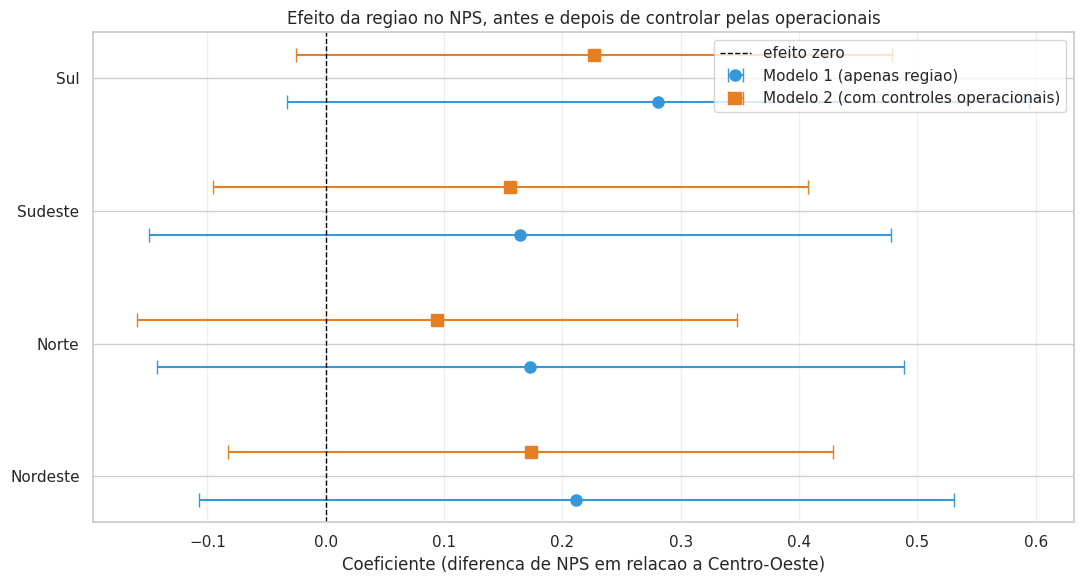

In [19]:
# Visualiza os coeficientes da regiao nos dois modelos lado a lado, com IC 95%
def extrair_coeficientes_regiao(modelo, sufixo: str) -> pd.DataFrame:
    params = modelo.params
    conf = modelo.conf_int(alpha=0.05)
    linhas = []
    for nome in params.index:
        if "customer_region" in nome:
            regiao = nome.split("T.")[-1].rstrip("]")
            linhas.append({
                "regiao": regiao,
                "modelo": sufixo,
                "coef": params[nome],
                "ic_min": conf.loc[nome, 0],
                "ic_max": conf.loc[nome, 1],
            })
    return pd.DataFrame(linhas)

coef_m1 = extrair_coeficientes_regiao(modelo_regiao, "Modelo 1 (apenas regiao)")
coef_m2 = extrair_coeficientes_regiao(modelo_controlado, "Modelo 2 (com controles)")
coef_combinado = pd.concat([coef_m1, coef_m2])

# Forest plot horizontal: cada regiao com IC 95% em dois modelos
fig, eixo = plt.subplots(figsize=(11, 6))

regioes = coef_m1["regiao"].tolist()
y_pos = np.arange(len(regioes))
deslocamento = 0.18

for i, regiao in enumerate(regioes):
    linha_m1 = coef_m1[coef_m1["regiao"] == regiao].iloc[0]
    linha_m2 = coef_m2[coef_m2["regiao"] == regiao].iloc[0]

    # Modelo 1 (azul, em cima)
    eixo.errorbar(
        linha_m1["coef"], i - deslocamento,
        xerr=[[linha_m1["coef"] - linha_m1["ic_min"]], [linha_m1["ic_max"] - linha_m1["coef"]]],
        fmt="o", color="#3498db", capsize=5, markersize=8,
        label="Modelo 1 (apenas regiao)" if i == 0 else "",
    )
    # Modelo 2 (laranja, em baixo)
    eixo.errorbar(
        linha_m2["coef"], i + deslocamento,
        xerr=[[linha_m2["coef"] - linha_m2["ic_min"]], [linha_m2["ic_max"] - linha_m2["coef"]]],
        fmt="s", color="#e67e22", capsize=5, markersize=8,
        label="Modelo 2 (com controles operacionais)" if i == 0 else "",
    )

eixo.axvline(0, color="black", linestyle="--", linewidth=1, label="efeito zero")
eixo.set_yticks(y_pos)
eixo.set_yticklabels(regioes)
eixo.set_xlabel("Coeficiente (diferenca de NPS em relacao a Centro-Oeste)")
eixo.set_title("Efeito da regiao no NPS, antes e depois de controlar pelas operacionais")
eixo.legend(loc="upper right")
eixo.grid(True, axis="x", alpha=0.3)
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "4_9_efeito_regiao.png", dpi=120, bbox_inches="tight")
plt.show()

![Coeficientes da região nos dois modelos com IC 95%](../reports/figures/04_eda/4_9_efeito_regiao.png)

**Como ler este gráfico:** cada linha do eixo Y é uma região comparada com a referência (Centro-Oeste). O eixo X mostra o **coeficiente estimado**: a quantidade que o NPS daquela região é maior ou menor do que a referência, em pontos da escala do NPS (de 0 a 10).

Para cada região aparecem **dois marcadores**: o **círculo azul (Modelo 1)** é o coeficiente estimado quando consideramos só a região como preditor, e o **quadrado laranja (Modelo 2)** é o coeficiente quando adicionamos as variáveis operacionais. As **linhas horizontais** que saem de cada marcador são os **intervalos de confiança a 95%** para o coeficiente.

A **linha tracejada vertical em zero** marca o "efeito zero". Se o intervalo de confiança de uma região cruza essa linha, significa que **não há evidência estatística de diferença entre essa região e a referência**.

**O que procurar:** se a hipótese H7 estivesse certa, os marcadores azuis (modelo simples) estariam afastados do zero, e os laranja (modelo controlado) estariam próximos do zero — a "diferença encolhe quando controlamos". Se ambos os marcadores estiverem perto do zero desde o início, é porque o efeito de região já era inexistente.

O gráfico confirma visualmente a leitura das tabelas. Os marcadores de todas as regiões estão **próximos do zero** e os intervalos de confiança **cruzam a linha do zero** em todas elas. Isso vale tanto para o Modelo 1 (apenas região) quanto para o Modelo 2 (com controles operacionais).

Em outras palavras: nenhuma região tem NPS estatisticamente diferente da Centro-Oeste, com ou sem controle. Os pequenos deslocamentos que aparecem na tabela (Sul mais alto, Centro-Oeste mais baixo) são variações dentro da margem de incerteza amostral, não diferenças genuínas.

### Limitações e interpretação final

Esta análise mostra duas coisas ao mesmo tempo. Tecnicamente, a hipótese H7 não pode ser nem confirmada nem rejeitada de forma significativa no dataset, porque a região simplesmente não explica nada do NPS aqui. A pergunta original ("o efeito da região é operacional ou cultural?") pressupõe que existe um efeito; como ele não existe, a comparação fica vazia.

Conceitualmente, esse resultado é **consistente com a hipótese de dataset sintético** que vinha sendo construída desde a seção 2.6. As cinco regiões foram distribuídas de forma quase idêntica em volume e, aparentemente, também de forma independente das variáveis operacionais. Em base real, não esperaríamos esse equilíbrio: regiões com infraestrutura logística melhor (Sudeste e Sul) tendem a ter tempo de entrega menor; clientes de regiões com poder aquisitivo maior tendem a ter expectativas mais altas. Nada disso aparece aqui.

**Para o slide executivo**, a recomendação é honesta: não cabe no nosso dataset fazer afirmação sobre comportamento regional. Se a empresa real quiser explorar essa dimensão, vai precisar enriquecer a base com dados externos do IBGE (renda média, urbanização) e validar a análise em base verdadeira de pedidos. O dataset atual não permite resposta confiável sobre região.

**Para o modelo preditivo (notebook 05)**, a região vai entrar como variável categórica do mesmo jeito, mas devemos esperar que ela contribua pouco. As variáveis dominantes vão continuar sendo as logísticas e de atendimento que apareceram nas hipóteses H4 e H5 — e principalmente o `delivery_delay_days`, que sozinho já explica 36% do NPS conforme vimos na seção 4.4.